# Rayong Crop Tracker · End-to-end pipeline

Sentinel-2 L2A → OpenSR super-resolution → diffusion-sampled minority-class augmentation → texture + index features → Random Forest cascade.

Stages map 1:1 to the [tracker board](../README.md). Heavy steps cache to disk so a kernel restart only costs a few imports.

## 1 · Setup

Use `notebooks/environment.yml` (`conda env create -f notebooks/environment.yml`). If you must pip-install, uncomment the cell below.


In [1]:
# !pip install -q --upgrade \
#     openeo "openeo-processes-dask[implementations]" pystac-client planetary-computer \
#     rasterio rioxarray xarray geopandas shapely pyproj fiona mgrs \
#     opensr-model omegaconf diffusers transformers accelerate safetensors \
#     scikit-image scikit-learn matplotlib seaborn tqdm pyarrow \
#     --extra-index-url https://download.pytorch.org/whl/cu121 "torch==2.3.1+cu121" torchvision torchaudio

In [1]:
from __future__ import annotations
import sys, json, math, warnings, datetime as dt
from pathlib import Path
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import rasterio
import rioxarray as rxr
import xarray as xr
import geopandas as gpd

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_context("notebook"); sns.set_style("whitegrid")
print("python:", sys.version.split()[0])


python: 3.12.13


In [2]:
def _repo_root_default() -> Path:
    if "__file__" in globals():
        return Path(__file__).resolve().parents[1]
    here = Path.cwd().resolve()
    for p in (here, *here.parents):
        if (p / "package.json").exists() and (p / "notebooks").exists():
            return p
    return here


# LU_CODE -> display name. Codes verified against LDD LU_DES_EN on
# data/landuse_ryg/LU_RYG_2567.dbf.
TAXONOMY: tuple[tuple[str, tuple[str, ...]], ...] = (
    ("Rice",        ("A101",)),
    ("Cassava",     ("A204",)),
    ("Pineapple",   ("A205",)),
    ("Para rubber", ("A302",)),
    ("Oil palm",    ("A303",)),
    ("Durian",      ("A403",)),
    ("Mango",       ("A407",)),
    ("Jackfruit",   ("A416",)),
    ("Coconut",     ("A405",)),
    ("Mangosteen",  ("A419",)),
    ("Longan",      ("A413",)),
    ("Rambutan",    ("A404",)),
    ("Langsat",     ("A420",)),
    ("Reservoir",   ("W101", "W102", "W103", "W201", "W202", "W203")),
    ("Others",      ()),
)
CLASS_NAMES: tuple[str, ...] = tuple(name for name, _ in TAXONOMY)
class_name_to_int: dict[str, int] = {name: i + 1 for i, name in enumerate(CLASS_NAMES)}
int_to_class_name: dict[int, str] = {v: k for k, v in class_name_to_int.items()}
OTHERS_INT: int = class_name_to_int["Others"]

_CODE_PREFIX_TO_NAME: dict[str, str] = {}
for _name, _codes in TAXONOMY:
    for _c in _codes:
        _CODE_PREFIX_TO_NAME[_c] = _name


def lu_code_to_class_name(code: str | float | None) -> str:
    if not isinstance(code, str) or not code:
        return "Others"
    if code in _CODE_PREFIX_TO_NAME:
        return _CODE_PREFIX_TO_NAME[code]
    head = code[:4]
    return _CODE_PREFIX_TO_NAME.get(head, "Others")


@dataclass
class Config:
    repo_root:   Path = field(default_factory=_repo_root_default)
    work_root:   Path = None
    cache_root:  Path = None
    out_root:    Path = None
    ldd_landuse: Path = None
    ldd_admin:   Path = None

    aoi_quadrant: str   = "SE"        # FULL / NW / NE / SW / SE / CUSTOM
    aoi_bbox:     tuple = (101.4291, 12.5834, 101.8305, 12.8539)
    aoi_name:     str   = "rayong_se"

    time_start: str = "2024-10-01"
    time_end:   str = "2024-12-31"

    smoke_test:           bool  = False
    smoke_bbox_deg:       float = 0.025
    smoke_months:         int   = 2
    smoke_rf_estimators:  int   = 200
    smoke_sr_steps:       int   = 25
    full_sr_steps:        int   = 50

    bands_10m: tuple = ("B02", "B03", "B04", "B08")
    bands_20m: tuple = ("B05", "B06", "B07", "B11", "B12")
    scl_band:  str   = "SCL"

    sr_scale: int = 4
    sr_steps: int = 50

    minority_classes:  tuple = (
        "Mango", "Rambutan", "Langsat", "Longan", "Mangosteen",
        "Coconut", "Jackfruit",
    )
    quadrants:        tuple = ("NW", "NE", "SW", "SE")
    samples_per_minor: int   = 600

    rf_n_estimators: int  = 600
    rf_max_depth:    int  = None
    cascade:         bool = True
    seed:            int  = 42

    def __post_init__(self):
        data = self.repo_root / "data"
        self.work_root   = self.work_root   or data
        self.cache_root  = self.cache_root  or data / "_cache"
        self.out_root    = self.out_root    or data / "_out"
        self.ldd_landuse = self.ldd_landuse or data / "landuse_ryg"
        self.ldd_admin   = self.ldd_admin   or data / "admin_ryg"
        self.sr_steps = self.smoke_sr_steps if self.smoke_test else self.full_sr_steps
        if self.smoke_test:
            self.rf_n_estimators = self.smoke_rf_estimators


_W, _S, _E, _N = 100.9845, 12.5834, 101.8305, 13.1635
_CLNG, _CLAT  = 101.4291, 12.8539
QUADRANT_BBOX = {
    "FULL": (_W, _S, _E, _N),
    "NW":   (_W,    _CLAT, _CLNG, _N),
    "NE":   (_CLNG, _CLAT, _E,    _N),
    "SW":   (_W,    _S,    _CLNG, _CLAT),
    "SE":   (_CLNG, _S,    _E,    _CLAT),
}

CFG = Config()
if CFG.aoi_quadrant != "CUSTOM":
    if CFG.aoi_quadrant not in QUADRANT_BBOX:
        raise ValueError(f"unknown aoi_quadrant '{CFG.aoi_quadrant}'")
    CFG.aoi_bbox = QUADRANT_BBOX[CFG.aoi_quadrant]
    CFG.aoi_name = f"rayong_{CFG.aoi_quadrant.lower()}"

if CFG.smoke_test:
    w, s, e, n = CFG.aoi_bbox
    cx, cy = (w + e) / 2, (s + n) / 2
    d = CFG.smoke_bbox_deg
    CFG.aoi_bbox = (cx - d, cy - d, cx + d, cy + d)
    start = pd.to_datetime(CFG.time_start)
    end_target = start + pd.DateOffset(months=CFG.smoke_months)
    if pd.to_datetime(CFG.time_end) > end_target:
        CFG.time_end = end_target.strftime("%Y-%m-%d")
    CFG.aoi_name = f"{CFG.aoi_name}_smoke"

for d in (CFG.cache_root, CFG.out_root, CFG.out_root / "figs"):
    d.mkdir(parents=True, exist_ok=True)

mode = "SMOKE TEST" if CFG.smoke_test else "FULL LOAD"
full_w, full_s, full_e, full_n = QUADRANT_BBOX["FULL"]
print(f"[{mode}] full Rayong · bbox ({full_w}, {full_s}, {full_e}, {full_n})")
print(f"          quadrants the §5 driver iterates:")
for _q in CFG.quadrants:
    _w, _s, _e, _n = QUADRANT_BBOX[_q]
    print(f"            {_q:<2s} · bbox ({_w}, {_s}, {_e}, {_n}) · name rayong_{_q.lower()}")
print(f"          single-AOI sanity flow runs on: {CFG.aoi_quadrant} ({CFG.aoi_name})")
print(f"          time   {CFG.time_start} → {CFG.time_end}")
print(f"          sr_steps {CFG.sr_steps} · rf_n_estimators {CFG.rf_n_estimators}")
print(f"          classes {len(CLASS_NAMES)} · minority {CFG.minority_classes}")
if CFG.smoke_test:
    print("          flip CFG.smoke_test = False in this cell to run the full load.")


[FULL LOAD] AOI SE · bbox (101.4291, 12.5834, 101.8305, 12.8539) · name rayong_se
          time   2024-10-01 → 2024-12-31
          sr_steps 50 · rf_n_estimators 600
          classes 15 · minority ('Mango', 'Rambutan', 'Langsat', 'Longan', 'Mangosteen', 'Coconut', 'Jackfruit')


In [3]:
import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} · {DEVICE}")
if DEVICE == "cuda":
    print(f"  gpu: {torch.cuda.get_device_name(0)} · {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


torch 2.3.1+cu121 · cuda
  gpu: NVIDIA GeForce RTX 3080 · 10.7 GB


## 2 · Sentinel-2 L2A · monthly medians via CDSE

OIDC login on first run. Result cached as one GeoTIFF per month.


In [4]:
import openeo
CONN = openeo.connect("openeo.dataspace.copernicus.eu")
try:    CONN.authenticate_oidc()
except Exception as e: print("auth needed:", e)
print("connected:", CONN.capabilities().get("title", "CDSE openEO"))


Authenticated using refresh token.
connected: Copernicus Data Space Ecosystem openEO API


In [5]:
def s2_cache_dir(cfg: Config) -> Path:
    out = cfg.cache_root / "s2_monthly" / cfg.aoi_name
    out.mkdir(parents=True, exist_ok=True)
    return out


S2_TARGET_CRS = "EPSG:32647"   # UTM 47N -- force every MGRS tile onto the same grid
S2_EDGE_BUFFER_DEG = 0.005     # ~500 m bbox buffer so reprojection rounding does not strip slivers


def _buffered_bbox(cfg: Config) -> dict:
    w, s, e, n = cfg.aoi_bbox
    b = S2_EDGE_BUFFER_DEG
    return dict(west=w - b, south=s - b, east=e + b, north=n + b, crs="EPSG:4326")


def fetch_s2_monthly_median(cfg: Config, force: bool = False) -> Path:
    """Cloud-masked monthly-median S2. Skips the openEO job if cache exists."""
    out = s2_cache_dir(cfg)
    cached = sorted(out.glob("*.tif"))
    if cached and not force:
        print(f"cache hit · {len(cached)} files")
        return out

    bbox = _buffered_bbox(cfg)
    print(f"openEO request bbox (buffered +{S2_EDGE_BUFFER_DEG}°): {bbox}")
    bands = list(cfg.bands_10m) + list(cfg.bands_20m) + [cfg.scl_band]

    cube = CONN.load_collection("SENTINEL2_L2A",
                                spatial_extent=bbox,
                                temporal_extent=[cfg.time_start, cfg.time_end],
                                bands=bands, max_cloud_cover=85)
    scl = cube.band(cfg.scl_band)
    cube = cube.mask((scl == 3) | (scl == 8) | (scl == 9) | (scl == 10))
    cube = cube.filter_bands(list(cfg.bands_10m) + list(cfg.bands_20m))
    cube = cube.resample_spatial(
        resolution=10,
        method="bilinear",
        projection=int(S2_TARGET_CRS.split(":")[1]),
    )
    cube = cube.aggregate_temporal_period(period="month", reducer="median")

    job = cube.execute_batch(title=f"S2 monthly · {cfg.aoi_name}", out_format="GTiff")
    job.get_results().download_files(str(out))

    new_tifs = sorted(out.glob("*.tif"))
    if new_tifs:
        try:
            import rioxarray as rxr  # noqa: F401
            a = rxr.open_rasterio(new_tifs[0])
            b = a.rio.bounds()
            print(f"first tile bounds (in raster CRS {a.rio.crs}): {b}")
        except Exception as e:
            print(f"  (could not inspect first tile bounds: {e})")
    return out


cache hit · 12 files


In [7]:
def load_s2_stack(s2_dir: Path) -> xr.DataArray:
    """Concat cached monthly S2 tifs into (time, band, y, x), filtered to CFG window."""
    tifs = sorted(s2_dir.glob("*.tif"))
    window_start = pd.to_datetime(CFG.time_start).replace(day=1)
    window_end   = pd.to_datetime(CFG.time_end)
    arrs = []
    kept = []
    skipped = []
    for p in tifs:
        month = "".join(c for c in p.stem if c.isdigit())[:6]
        if len(month) < 6:
            continue
        ts = pd.to_datetime(month, format="%Y%m")
        if ts < window_start or ts > window_end:
            skipped.append(str(ts.date())[:7])
            continue
        a = rxr.open_rasterio(p, masked=True).astype("float32")
        a = a.expand_dims(time=[ts])
        arrs.append(a)
        kept.append(str(ts.date())[:7])
    if not arrs:
        raise RuntimeError(
            f"No cached S2 months inside [{CFG.time_start}, {CFG.time_end}] under {s2_dir}.")
    stack = xr.concat(arrs, dim="time").rename({"band": "band_idx"})
    print(f"S2 stack {stack.shape} · crs {stack.rio.crs}")
    print(f"  months kept   : {kept}")
    if skipped:
        print(f"  months skipped: {skipped} (outside CFG window)")
    return stack


S2 stack (3, 9, 3151, 4503) · crs PROJCS["WGS 84 / UTM zone 47N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",99],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
  months kept   : ['2024-10', '2024-11', '2024-12']
  months skipped: ['2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09'] (outside CFG window)


## 3 · OpenSR · super-resolution ×4

`opensr_model.SRLatentDiffusion` on B02/B03/B04/B08. 4× upsample, reflectance out. 20 m bands stay native and are bilinearly upsampled when needed.


In [6]:
import opensr_model
from omegaconf import OmegaConf
from io import StringIO
import requests

_SR_CFG_URL = "https://raw.githubusercontent.com/ESAOpenSR/opensr-model/refs/heads/main/opensr_model/configs/config_10m.yaml"
_SR_MODEL = _SR_CFG = None


def get_sr_model():
    global _SR_MODEL, _SR_CFG
    if _SR_MODEL is None:
        _SR_CFG = OmegaConf.load(StringIO(requests.get(_SR_CFG_URL, timeout=30).text))
        _SR_MODEL = opensr_model.SRLatentDiffusion(_SR_CFG, device=DEVICE)
        _SR_MODEL.load_pretrained(_SR_CFG.ckpt_version)
        _SR_MODEL.eval()
        print(f"opensr-model loaded · ckpt {_SR_CFG.ckpt_version}")
    return _SR_MODEL


In [ ]:
@torch.no_grad()
def super_resolve_month(month_arr: xr.DataArray, tile: int = 128, overlap: int = 32, steps: int | None = None, desc: str = "tiles", batch_size: int = 4) -> xr.DataArray:
    """Tile-wise SR. Model expects (B, 4, 128, 128) and returns 4x upsampled.

    steps  : diffusion sampling count. Defaults to CFG.sr_steps (25 in smoke
             mode, 50 in full load). Pass 100 to match OpenSR's reference.
    desc   : label for the inner per-tile progress bar.
    """
    if steps is None:
        steps = CFG.sr_steps
    model = get_sr_model()
    rgb_nir = month_arr.isel(band_idx=slice(0, 4)).values.astype("float32") / 10000.0
    C, H, W = rgb_nir.shape
    out = np.zeros((C, H * CFG.sr_scale, W * CFG.sr_scale), dtype="float32")
    cnt = np.zeros_like(out[0])

    step = tile - overlap
    coords = [(y, x) for y in range(0, H, step) for x in range(0, W, step)]
    # Build per-tile (patch, meta) once so we can feed N at a time to
    # model.forward. opensr-ldsrs2 accepts (B, 4, 128, 128).
    patches, metas = [], []
    for (y, x) in coords:
        patch = rgb_nir[:, y:y+tile, x:x+tile]
        ph, pw = patch.shape[1], patch.shape[2]
        if ph < 16 or pw < 16:
            continue
        if ph < tile or pw < tile:
            pad = np.zeros((C, tile, tile), dtype="float32")
            pad[:, :ph, :pw] = patch
            patch = pad
        patches.append(patch)
        metas.append((y, x, ph, pw))

    from tqdm import tqdm as _tqdm_text
    pbar = _tqdm_text(total=len(patches), desc=desc, leave=False, mininterval=0.5,
                      position=1, dynamic_ncols=True)
    for bstart in range(0, len(patches), batch_size):
        bend = min(bstart + batch_size, len(patches))
        batch_np = np.stack(patches[bstart:bend], axis=0)
        t = torch.from_numpy(batch_np).to(DEVICE)
        sr_batch = model.forward(t, sampling_steps=steps).cpu().numpy()
        for k in range(bend - bstart):
            y, x, ph, pw = metas[bstart + k]
            sr = sr_batch[k, :, :ph * CFG.sr_scale, :pw * CFG.sr_scale]
            ys, xs = y * CFG.sr_scale, x * CFG.sr_scale
            out[:, ys:ys+sr.shape[1], xs:xs+sr.shape[2]] += sr
            cnt[ys:ys+sr.shape[1], xs:xs+sr.shape[2]] += 1
        pbar.update(bend - bstart)
    pbar.close()
    out /= np.maximum(cnt[None], 1)

    sr_da = xr.DataArray(out, dims=("band_idx", "y", "x"), coords={"band_idx": list(range(C))})
    sr_da = sr_da.rio.write_crs(month_arr.rio.crs)
    sr_da = sr_da.rio.write_transform(month_arr.rio.transform() * rasterio.Affine.scale(1.0 / CFG.sr_scale))
    return sr_da


# Toggle per-month preview. Set False on long runs you don't want to watch.
SHOW_PREVIEW = True

def _preview_pair(nat_arr: np.ndarray, sr_arr: np.ndarray, title: str):
    """Quick native-vs-SR figure for a single month. nat/sr are (4, H, W) reflectance."""
    rgb = lambda a: np.clip(a[[2, 1, 0]] * 3.0, 0, 1).transpose(1, 2, 0)
    fig, ax = plt.subplots(1, 2, figsize=(10, 4.6))
    ax[0].imshow(rgb(nat_arr), interpolation="nearest")
    ax[0].set_title(f"native 10 m · {nat_arr.shape[2]}×{nat_arr.shape[1]} px")
    ax[0].axis("off")
    ax[1].imshow(rgb(sr_arr))
    ax[1].set_title(f"SR 2.5 m · {sr_arr.shape[2]}×{sr_arr.shape[1]} px")
    ax[1].axis("off")
    fig.suptitle(title, fontsize=10)
    plt.tight_layout()
    plt.show()

def sr_cache_dir_for(aoi_name: str) -> Path:
    out = CFG.cache_root / "s2_sr" / aoi_name
    out.mkdir(parents=True, exist_ok=True)
    return out


def build_or_load_sr_stack(s2_stack: xr.DataArray, aoi_name: str,
                           show_preview: bool = False) -> xr.DataArray:
    """Per-AOI SR loader. Reads each month from cache when present and only
    runs the diffusion sampler on missing tifs, so re-running on cached
    quadrants is near-instant."""
    cache_dir = sr_cache_dir_for(aoi_name)
    sr_stack = []
    for t in tqdm(list(s2_stack.time.values), desc=f"SR · {aoi_name}"):
        label = pd.to_datetime(t).strftime("%Y-%m")
        cache_p = cache_dir / f"sr_{pd.to_datetime(t).strftime('%Y%m')}.tif"
        if cache_p.exists():
            sr = rxr.open_rasterio(cache_p, masked=True).astype("float32")
        else:
            tqdm.write(f"[{aoi_name} · {label}] super-resolving (steps={CFG.sr_steps}) …")
            sr = super_resolve_month(s2_stack.sel(time=t), desc=f"{label} tiles")
            sr.rio.to_raster(cache_p, compress="DEFLATE", tiled=True)
        sr_stack.append(sr.expand_dims(time=[t]))

        if show_preview:
            _nat = s2_stack.sel(time=t).isel(band_idx=slice(0, 4)).values.astype("float32") / 10000.0
            _srv = sr.values.astype("float32")
            if _srv.max() > 5:
                _srv = _srv / 10000.0
            _preview_pair(_nat, _srv, f"{label} · {aoi_name}")
    stack = xr.concat(sr_stack, dim="time")
    print(f"SR stack {stack.shape} · res {stack.rio.resolution()} · aoi {aoi_name}")
    return stack


def load_sr_stack_from_cache(aoi_name: str, chunks: dict | None = None) -> xr.DataArray:
    """Load every cached SR month for `aoi_name` as a dask-backed lazy
    xarray. `chunks` is forwarded to rioxarray.open_rasterio so individual
    .values calls materialise only the slice they need -- without this
    the xr.concat eagerly stitches 4 timesteps x 4 bands x 12604 x 18012
    float32 into one ~14 GiB allocation and trips MemoryError on 16 GiB
    boxes. Time coords come from the `sr_YYYYMM.tif` filename, no S2
    dependency."""
    cache_dir = sr_cache_dir_for(aoi_name)
    tifs = sorted(cache_dir.glob("sr_*.tif"))
    if not tifs:
        raise FileNotFoundError(
            f"No SR cache under {cache_dir}. Either run §3 build_or_load_sr_stack "
            f"to generate it, or copy the pre-computed sr_YYYYMM.tif files in.")
    if chunks is None:
        chunks = {"x": 2048, "y": 2048}
    sr_stack = []
    # Filter to CFG.time_start / CFG.time_end so leftover monthly tifs from
    # earlier full-year runs (e.g. sr_202401.tif under rayong_se) do not
    # poison the concat. Misaligned bounds between months -> xr.concat
    # outer-joins the y/x indices -> transform anchors shift -> rasterise
    # paints almost nothing (SE saw 0.4 % non-zero from a stray Jan tif).
    window_start = pd.to_datetime(CFG.time_start).replace(day=1)
    window_end   = pd.to_datetime(CFG.time_end)
    skipped = []
    for p in tifs:
        ym = "".join(c for c in p.stem if c.isdigit())[:6]
        if len(ym) < 6:
            continue
        t = pd.to_datetime(ym, format="%Y%m")
        if t < window_start or t > window_end:
            skipped.append(str(t.date())[:7])
            continue
        sr = rxr.open_rasterio(p, masked=True, chunks=chunks)
        sr_stack.append(sr.expand_dims(time=[t]))
    if skipped:
        print(f"  SR cache skipped (outside CFG window): {skipped}")
    if not sr_stack:
        raise RuntimeError(
            f"No SR cache months inside [{CFG.time_start}, {CFG.time_end}] under {cache_dir}.")
    # join="exact" so an accidental cross-month bbox mismatch raises loudly
    # instead of silently outer-joining into a misaligned super-grid.
    stack = xr.concat(sr_stack, dim="time", join="exact")
    print(f"SR stack (cache-only, dask-chunked) {stack.shape} · res {stack.rio.resolution()} · aoi {aoi_name}")
    return stack





## 4 · Rasterise LDD landuse onto the SR grid

LDD shapefile → label raster co-registered with the SR stack. Sets `LABELS`; downstream code uses it for `extract_class_patches` and `build_pixel_table`.

In [ ]:
from rasterio.features import rasterize

_shp_candidates = list(CFG.ldd_landuse.rglob("*.shp"))
if not _shp_candidates:
    raise FileNotFoundError(
        f"No .shp found under {CFG.ldd_landuse}. "
        f"Drop the LDD landuse shapefile (LU_RYG_*.shp + .shx/.dbf/.prj/.cpg) "
        f"into that folder and re-run. See data/README.md for layout.")
LU_SHP = _shp_candidates[0]
if len(_shp_candidates) > 1:
    print(f"note: found {len(_shp_candidates)} shapefiles, using {LU_SHP.name}")
print("LDD landuse:", LU_SHP.name)


def load_landuse_for(sr_da: xr.DataArray) -> "gpd.GeoDataFrame":
    """Read LDD shapefile, reproject to sr_da's CRS, map LU_CODE -> taxonomy."""
    gdf = gpd.read_file(LU_SHP).to_crs(sr_da.rio.crs)
    gdf["class_name"] = gdf["LU_CODE"].map(lu_code_to_class_name)
    gdf["lu_int"]     = gdf["class_name"].map(class_name_to_int).astype("int32")
    return gdf


def count_polygons_in_aoi(gdf: "gpd.GeoDataFrame", sr_da: xr.DataArray) -> "gpd.GeoDataFrame":
    """Spatial clip of gdf to sr_da bounds. Diagnostic only -- rasterize gets the full gdf."""
    minx, miny, maxx, maxy = sr_da.rio.bounds()
    return gdf.cx[minx:maxx, miny:maxy]


def rasterize_labels(lu_gdf: "gpd.GeoDataFrame", sr_da: xr.DataArray) -> np.ndarray:
    out_shape = sr_da.isel(time=0).shape[1:]
    return rasterize(
        [(g, v) for g, v in zip(lu_gdf.geometry, lu_gdf["lu_int"]) if v > 0],
        out_shape=out_shape, transform=sr_da.rio.transform(), fill=0, dtype="int32",
    )


In [ ]:
# Crop context-rich windows that CONTAIN a target minority class instead of
# bagging individual class pixels. Each window is a full SR-resolution crop
# centred (with jitter) on a random class pixel, sized big enough to keep
# the surrounding environment - orchard edges, neighbouring crops, roads,
# water. Concatenated single pixels lose all of that, which is why the
# diffusion-trained patches read as noise rather than as plausible scenes.
#
# At x4 SR over 10 m Sentinel-2 each pixel is ~2.5 m, so:
#   128 px (320 m)  - prior default, smaller than opensr-ldsrs2's training tile
#   512 px (1280 m) - matches opensr's 128-LR x 4 = 512-SR training scale exactly
#                     and removes the inference-time LR clamp + train/inference skew
#
# WINDOW_PX = 512 is the default because LR_DIV=4 in the LoRA cell yields a
# 128-px native LR, which is the tile size super_resolve_month feeds the
# diffusion model. Anything smaller required a bilinear-up clamp at sample
# time, leaving a small train/inference distribution gap.

WINDOW_PX = 512                       # SR-pixel side length of the training crop
#                                      512 SR-px @ 2.5 m = 1280 m FOV. LR_DIV=4 -> 128 LR-px
#                                      natively, matches opensr-ldsrs2 tile size exactly so
#                                      MIN_LR_PX clamp never fires and the model sees a real
#                                      LR distribution at inference. Cleaner synth than the
#                                      WINDOW_PX=256 path which had to bilinear-up 64 -> 128.
#                                      Memory: ~4 MB/patch * 600 * 7 = 16.8 GB pooled. Fits
#                                      64 GB with the driver-side gc that frees per-AOI SR
#                                      and labels after each quadrant.
MIN_CLASS_FRAC = 0.003                # >= 0.3 % of the window must be class (was 0.005)
CENTER_JITTER_FRAC = 1 / 2            # +/- (window/2 x this) random shift on the centre (was 1/3)
MAX_TRIES_FACTOR = 10                 # cap rejection-sampling attempts at n * this


def extract_class_context_windows(class_name: str, sr_da: xr.DataArray,
                                  labels_arr: np.ndarray,
                                  n: int = 200,
                                  window_px: int = WINDOW_PX,
                                  min_class_frac: float = MIN_CLASS_FRAC,
                                  seed: int = 0):
    """Return ((N, 4, window_px, window_px) reflectance,
              (N, window_px, window_px) class mask)
    drawn from the supplied SR DataArray and label raster.

    Diversification levers compared to the prior single-pass loop:
      * **with-replacement** centre sampling so abundant classes can yield
        far more than ``len(yy)`` distinct windows, and sparse classes
        revisit the same centres but get distinct jitter / time / spectra;
      * **random time index** per window (instead of a single mid-month
        slice) so each polygon contributes one window per cached month
        free of charge - same class texture, distinct seasonality;
      * **CENTER_JITTER_FRAC = 1/2** so the same centre yields ~4x more
        unique compositions before the class mask drops below the
        threshold;
      * **MIN_CLASS_FRAC relaxed to 0.003** so smaller polygons qualify.

    The mask flags pixels of ``class_name`` inside the window so the LoRA
    loss can up-weight them (mask-weighted MSE in cell 25). Returns
    empty arrays when the class is absent in this AOI.
    """
    cls = class_name_to_int.get(class_name)
    if cls is None:
        return (np.empty((0, 4, window_px, window_px), dtype="float32"),
                np.empty((0, window_px, window_px), dtype="bool"))
    yy, xx = np.where(labels_arr == cls)
    if len(yy) == 0:
        return (np.empty((0, 4, window_px, window_px), dtype="float32"),
                np.empty((0, window_px, window_px), dtype="bool"))
    rng = np.random.RandomState(seed)
    H, W = labels_arr.shape
    half = window_px // 2
    jitter = max(1, int(half * CENTER_JITTER_FRAC))
    min_pixels = max(1, int(min_class_frac * window_px * window_px))

    # Per-window dask slicing instead of caching whole 3.6 GiB timesteps.
    # `sr_da` is dask-backed by load_sr_stack_from_cache(), so the .values
    # call below materialises only the (4, window_px, window_px) slice
    # for one timestep -- ~4 MB transient. Memory stays flat regardless
    # of how many windows we extract.
    times = list(sr_da.time.values)

    imgs, masks = [], []
    tries = 0
    max_tries = max(n * MAX_TRIES_FACTOR, len(yy) * 2)
    while len(imgs) < n and tries < max_tries:
        tries += 1
        i = int(rng.randint(0, len(yy)))
        ti = int(rng.randint(0, len(times)))
        y, x = int(yy[i]), int(xx[i])
        y += int(rng.randint(-jitter, jitter + 1))
        x += int(rng.randint(-jitter, jitter + 1))
        y0, x0 = y - half, x - half
        y1, x1 = y0 + window_px, x0 + window_px
        if y0 < 0 or x0 < 0 or y1 > H or x1 > W:
            continue
        m = (labels_arr[y0:y1, x0:x1] == cls)
        if int(m.sum()) < min_pixels:
            continue
        sub = sr_da.isel(time=ti, y=slice(y0, y1), x=slice(x0, x1)).values
        if sub.max() > 5:
            sub = sub / 10000.0
        # NoData rejection. Black = all 4 bands == 0 at same (y, x);
        # NaN = openEO cloud mask or SR tile-edge pad. >5 % NoData ->
        # skip so neither LoRA training nor inference seeds see bad windows.
        nodata_frac = float(((sub == 0).all(axis=0) | np.isnan(sub).any(axis=0)).mean())
        if nodata_frac > 0.05:
            continue
        imgs.append(sub.astype("float32"))
        masks.append(m)
    if not imgs:
        return (np.empty((0, 4, window_px, window_px), dtype="float32"),
                np.empty((0, window_px, window_px), dtype="bool"))
    return np.stack(imgs).astype("float32"), np.stack(masks)


# Back-compat alias preserved so the rest of the notebook can still call
# the simpler patch-only signature with the current AOI's globals.
def extract_class_patches(class_name: str, n: int = 200, size: int = WINDOW_PX) -> np.ndarray:
    imgs, _ = extract_class_context_windows(class_name, SR, LABELS, n=n, window_px=size,
                                            seed=CFG.seed)
    return imgs



## 4.5 · Pixel feature table helpers

Monthly band stats + NDVI/NDWI per stride-sampled AOI pixel. Synthetic rows from §6 are concatenated here, so the classifier sees real + synthetic in a single frame.

In [ ]:
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern

# Index helpers used in build_pixel_table. SR-only indices keep the table
# light and avoid having to keep a parallel 20 m S2 stack in memory
# alongside the 4-band SR stack:
#   NDVI = (B08 - B04) / (B08 + B04)
#   EVI  = 2.5 * (B08 - B04) / (B08 + 6*B04 - 7.5*B02 + 1)
#   NDWI = (B03 - B08) / (B03 + B08)   (McFeeters)
#
# MTCI / NDWI_SWIR / SWIR_* were dropped: they require Sentinel-2 20 m
# bands (B05/B06/B11), and we now load only the 4-band SR stack from
# cache so MemoryError on the 14 GiB float32 concat goes away.


_B10_NAMES = ("B02", "B03", "B04", "B08")


def build_pixel_table(sr_da: xr.DataArray, labels_arr: np.ndarray,
                      s2_da: xr.DataArray | None = None,
                      stride: int = 8,
                      max_pixels_per_class: int = 100_000) -> pd.DataFrame:
    """Stride-sample the SR grid wherever a label exists and build the
    feature table the RF trains on. `s2_da` is accepted for API
    compatibility with older callers but is ignored -- the 20 m indices
    that used to depend on it (MTCI / NDWI_SWIR / SWIR_*) are no longer
    emitted. Per-timestep arrays are released between iterations so
    transient memory peaks at one timestep (~3.6 GiB on the SR grid)
    instead of materialising the full 4-month stack at once."""
    n_t = len(sr_da.time)
    H, W = labels_arr.shape
    yy, xx = np.meshgrid(np.arange(0, H, stride), np.arange(0, W, stride), indexing="ij")
    yy, xx = yy.ravel(), xx.ravel()
    keep = labels_arr[yy, xx] > 0
    yy, xx = yy[keep], xx[keep]

    # Per-class pixel cap. Dominant classes (Para rubber, Oil palm,
    # Others) otherwise contribute > 1 M pixels each in a single AOI
    # and swamp the RF + DF memory. Subsample uniformly within each
    # class so the cap is per-class per-AOI; sparse classes pass
    # through untouched.
    if max_pixels_per_class > 0:
        lbls = labels_arr[yy, xx]
        keep_mask = np.zeros(len(yy), dtype=bool)
        rng_cap = np.random.RandomState(0)
        for cls_int in np.unique(lbls):
            idx = np.where(lbls == cls_int)[0]
            if len(idx) > max_pixels_per_class:
                idx = rng_cap.choice(idx, size=max_pixels_per_class, replace=False)
            keep_mask[idx] = True
        yy, xx = yy[keep_mask], xx[keep_mask]
    print(f"  sampled {len(yy):,} pixels (stride={stride}, cap/class={max_pixels_per_class:,})")

    # SR 4-band time series at sampled pixel locations only. Memory is
    # 4 * n_t * N float32 -- about 56 MB at stride=8 on a 12k x 18k grid.
    spec = np.zeros((len(yy), n_t, 4), dtype="float32")
    for ti, t in enumerate(sr_da.time.values):
        sr_t = sr_da.isel(time=ti).values
        if sr_t.max() > 5:
            sr_t = sr_t / 10000.0
        spec[:, ti, :] = sr_t[:, yy, xx].T
        del sr_t

    # Slim feature set (12 columns total). Dropped p90 / min / max per band
    # and NDVI_max / EVI_max because they correlate heavily with mean and
    # std on a 3-month window. Temporal signal stays via std (per band)
    # and NDVI_amp (phenology range).
    stats: dict = {}
    for b, name in enumerate(_B10_NAMES):
        stats[f"{name}_mean"] = spec[:, :, b].mean(axis=1)
        stats[f"{name}_std"]  = spec[:, :, b].std(axis=1)

    b02 = spec[:, :, 0]
    b03 = spec[:, :, 1]
    b04 = spec[:, :, 2]
    b08 = spec[:, :, 3]
    eps = 1e-6
    ndvi = (b08 - b04) / (b08 + b04 + eps)
    ndwi = (b03 - b08) / (b03 + b08 + eps)
    evi  = 2.5 * (b08 - b04) / (b08 + 6.0 * b04 - 7.5 * b02 + 1.0 + eps)
    stats["NDVI_mean"] = ndvi.mean(axis=1)
    stats["NDVI_amp"]  = ndvi.max(axis=1) - ndvi.min(axis=1)
    stats["NDWI_mean"] = ndwi.mean(axis=1)
    stats["EVI_mean"]  = evi.mean(axis=1)

    df = pd.DataFrame(stats)
    df["y"], df["x"], df["label"] = yy, xx, labels_arr[yy, xx]
    df["_synth"] = False
    return df


def _save_df(df: pd.DataFrame, base: Path) -> Path:
    try:
        path = base.with_suffix(".parquet")
        df.to_parquet(path)
        return path
    except Exception as e:
        path = base.with_suffix(".pkl")
        df.to_pickle(path)
        print(f"  parquet unavailable ({type(e).__name__}); wrote pickle: {path.name}")
        print( "  install pyarrow into THIS kernel + restart:  %pip install pyarrow")
        return path


## 5 · Full Rayong load · pool windows + pixel tables across NW / NE / SW / SE

Canonical entry. Loops `CFG.quadrants`, reads SR direct from cache, rasterises labels per AOI, pools per-class windows up to `samples_per_minor`, concatenates per-AOI pixel tables into `DF`. Sanity-AOI globals (`SR`, `LABELS`, `lu`) bound at the end so §6 viz cells work without a re-load.

Cached to `<out_root>/pixel_table_full.parquet` so a kernel restart can skip the driver entirely and §8 RF lazy-reloads.


In [ ]:
from copy import deepcopy

AOI_QUADRANTS = tuple(CFG.quadrants)
print(f"full Rayong driver -> {AOI_QUADRANTS}")


def _clone_cfg_for(quadrant: str) -> "Config":
    cfg = deepcopy(CFG)
    cfg.aoi_quadrant = quadrant
    cfg.aoi_bbox     = QUADRANT_BBOX[quadrant]
    cfg.aoi_name     = f"rayong_{quadrant.lower()}"
    return cfg


sr_by_aoi:     dict[str, "xr.DataArray"]    = {}
lu_by_aoi:     dict[str, "gpd.GeoDataFrame"] = {}
labels_by_aoi: dict[str, np.ndarray]        = {}

pooled_patches: dict[str, list[np.ndarray]] = {c: [] for c in CFG.minority_classes}
pooled_masks:   dict[str, list[np.ndarray]] = {c: [] for c in CFG.minority_classes}
per_aoi_tables: list[pd.DataFrame] = []
per_aoi_stats:  list[dict]         = []

import gc

# Per-AOI cap so pooled_patches never grows past CFG.samples_per_minor before
# the final concat -- without this, peak ~67 GB on 7 classes x 4 AOIs x 600.
PER_AOI_WINDOW_CAP = max(1, CFG.samples_per_minor // len(AOI_QUADRANTS))
print(f"per-AOI window cap per class: {PER_AOI_WINDOW_CAP}  "
      f"(samples_per_minor={CFG.samples_per_minor} / {len(AOI_QUADRANTS)} quadrants)")

_seen_bounds: dict[tuple, str] = {}

for q in AOI_QUADRANTS:
    cfg_q = _clone_cfg_for(q)
    sr_q = load_sr_stack_from_cache(cfg_q.aoi_name)
    bounds_q = tuple(round(b, 0) for b in sr_q.rio.bounds())
    if bounds_q in _seen_bounds:
        print(f"[{q}] WARNING SR cache bounds identical to {_seen_bounds[bounds_q]}")
    else:
        _seen_bounds[bounds_q] = q
    print(f"[{q}] SR shape {tuple(sr_q.shape)} bounds {bounds_q} crs {sr_q.rio.crs}")
    lu_q = load_landuse_for(sr_q)
    labels_q = rasterize_labels(lu_q, sr_q)
    nonzero_pct = (labels_q > 0).mean()
    print(f"[{q}] labels {labels_q.shape} · non-zero {nonzero_pct:.2%}")

    n_windows = {}
    for cls in CFG.minority_classes:
        imgs, masks = extract_class_context_windows(
            cls, sr_q, labels_q,
            n=PER_AOI_WINDOW_CAP,
            seed=CFG.seed + AOI_QUADRANTS.index(q),
        )
        n_windows[cls] = len(imgs)
        if len(imgs):
            pooled_patches[cls].append(imgs)
            pooled_masks[cls].append(masks)
        del imgs, masks
    per_aoi_stats.append({"aoi": q, "labels_nonzero_pct": float(nonzero_pct), **n_windows})

    df_q = build_pixel_table(sr_q, labels_q, stride=8)
    df_q["aoi"] = q
    per_aoi_tables.append(df_q)

    # Keep only the sanity AOI globally; free the others.
    if q == CFG.aoi_quadrant:
        sr_by_aoi[q]     = sr_q
        lu_by_aoi[q]     = lu_q
        labels_by_aoi[q] = labels_q
    else:
        del sr_q, lu_q, labels_q
    gc.collect()

rng_pool = np.random.RandomState(CFG.seed + 91)
patches_by_class: dict[str, np.ndarray] = {}
masks_by_class:   dict[str, np.ndarray] = {}
for cls in CFG.minority_classes:
    if not pooled_patches[cls]:
        print(f"  {cls}: 0 windows across all AOIs, skipping")
        continue
    imgs_pool  = np.concatenate(pooled_patches[cls],  axis=0)
    masks_pool = np.concatenate(pooled_masks[cls],    axis=0)
    if len(imgs_pool) > CFG.samples_per_minor:
        sel = rng_pool.choice(len(imgs_pool), size=CFG.samples_per_minor, replace=False)
        imgs_pool, masks_pool = imgs_pool[sel], masks_pool[sel]
    patches_by_class[cls] = imgs_pool
    masks_by_class[cls]   = masks_pool
    print(f"  {cls}: pooled {len(imgs_pool):4d} windows (cap {CFG.samples_per_minor})")

print("\nper-AOI window summary:")
print(pd.DataFrame(per_aoi_stats).to_string(index=False))

DF_full = pd.concat(per_aoi_tables, ignore_index=True)
print(f"\nfull-load pixel table: {DF_full.shape}  rows across {len(per_aoi_tables)} AOIs")
DF = DF_full

# Cache so a kernel restart skips the full per-AOI compute.
OUT_DF_FULL = _save_df(DF, CFG.out_root / "pixel_table_full")
print(f"cached multi-AOI DF -> {OUT_DF_FULL}")

# Bind sanity-AOI globals for §6 viz cells.
_sanity_aoi = CFG.aoi_quadrant if CFG.aoi_quadrant in sr_by_aoi else (
    next(iter(sr_by_aoi.keys())) if sr_by_aoi else AOI_QUADRANTS[0]
)
SR_DIR  = sr_cache_dir_for(f"rayong_{_sanity_aoi.lower()}")
if _sanity_aoi not in sr_by_aoi:
    sr_by_aoi[_sanity_aoi]     = load_sr_stack_from_cache(f"rayong_{_sanity_aoi.lower()}")
    lu_by_aoi[_sanity_aoi]     = load_landuse_for(sr_by_aoi[_sanity_aoi])
    labels_by_aoi[_sanity_aoi] = rasterize_labels(lu_by_aoi[_sanity_aoi], sr_by_aoi[_sanity_aoi])
SR      = sr_by_aoi[_sanity_aoi]
lu      = lu_by_aoi[_sanity_aoi]
LABELS  = labels_by_aoi[_sanity_aoi]
print(f"\nsanity AOI for §6 viz: {_sanity_aoi}  (override via CFG.aoi_quadrant)")
DF.head()


## 6 · Native vs SR

Three views: full AOI side-by-side at native 10 m and SR 2.5 m, a zoomed crop to see per-pixel detail, and a monthly thumbnail strip.

In [ ]:
def to_rgb(arr: np.ndarray, gain: float = 3.0) -> np.ndarray:
    """Reflectance (4, H, W) -> uint8 RGB (H, W, 3). Band order: B02 B03 B04 B08."""
    rgb = np.clip(arr[[2, 1, 0]] * gain, 0, 1)
    return (rgb.transpose(1, 2, 0) * 255).astype("uint8")


# Lazy-load S2 for the sanity AOI so this cell can show a native vs SR
# comparison even though the §5 driver does not bind S2 globally. If no
# S2 cache exists for the sanity quadrant we just show SR on both panels
# (still useful for eyeballing SR quality).
if "S2" not in globals():
    _sanity_aoi = CFG.aoi_quadrant if "sr_by_aoi" in globals() and CFG.aoi_quadrant in sr_by_aoi else None
    _aoi_for_s2 = _sanity_aoi if _sanity_aoi else CFG.aoi_quadrant
    _s2_dir = CFG.cache_root / "s2_monthly" / f"rayong_{_aoi_for_s2.lower()}"
    if _s2_dir.exists() and list(_s2_dir.glob("*.tif")):
        S2 = load_s2_stack(_s2_dir)
    else:
        S2 = None
        print(f"§6 native vs SR · no S2 cache under {_s2_dir} ; plotting SR only on both panels")

mid = SR.time.values[len(SR.time)//2]
sr_now = SR.sel(time=mid).values
if sr_now.max() > 5:
    sr_now = sr_now / 10000.0

fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
if S2 is not None:
    native = S2.sel(time=mid).isel(band_idx=slice(0, 4)).values / 10000.0
    ax[0].imshow(to_rgb(native))
    ax[0].set_title(f"Native 10 m · {native.shape[2]}x{native.shape[1]} px")
else:
    ax[0].imshow(to_rgb(sr_now))
    ax[0].set_title("Native 10 m unavailable (SR shown)")
ax[0].axis("off")
ax[1].imshow(to_rgb(sr_now))
ax[1].set_title(f"SR 2.5 m · {sr_now.shape[2]}x{sr_now.shape[1]} px")
ax[1].axis("off")
plt.suptitle(f"{CFG.aoi_name} · {pd.to_datetime(mid).strftime('%Y-%m')} · full AOI")
plt.tight_layout()
plt.savefig(CFG.out_root / "figs" / "native_vs_sr_full.png", dpi=160, bbox_inches="tight")
plt.show()


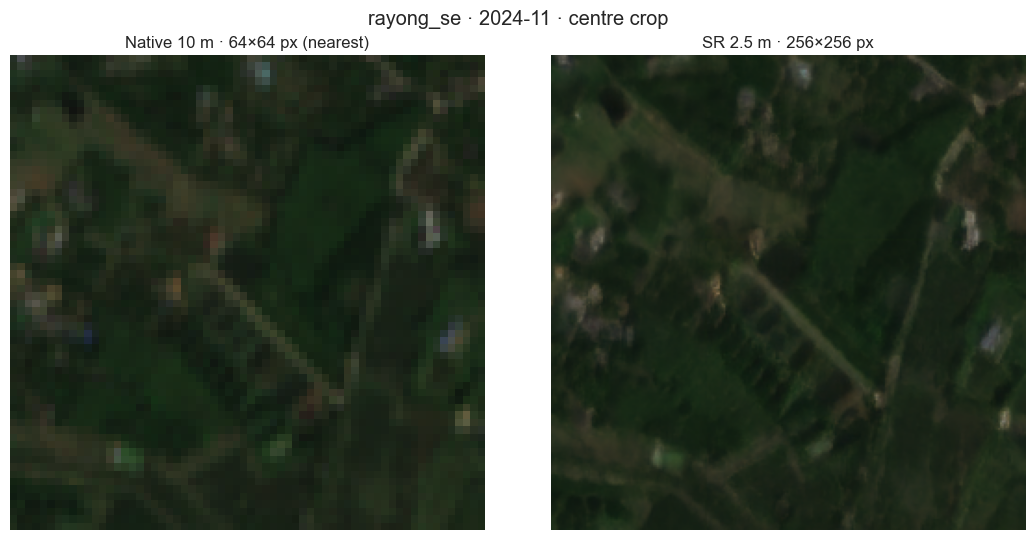

In [11]:
# zoomed crop: take a 64×64 native window (= 256×256 SR), centred on AOI.
H10, W10 = native.shape[1:]
cy, cx = H10 // 2, W10 // 2
win = 32
nat_crop = native[:, cy-win:cy+win, cx-win:cx+win]
sr_crop  = sr_now[:, cy*CFG.sr_scale - win*CFG.sr_scale: cy*CFG.sr_scale + win*CFG.sr_scale,
                     cx*CFG.sr_scale - win*CFG.sr_scale: cx*CFG.sr_scale + win*CFG.sr_scale]

fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
# nearest-neighbour resize the native crop to match SR pixel count, so the eye
# compares like-for-like instead of being fooled by the smaller native canvas.
ax[0].imshow(to_rgb(nat_crop), interpolation="nearest")
ax[0].set_title(f"Native 10 m · {nat_crop.shape[2]}×{nat_crop.shape[1]} px (nearest)")
ax[0].axis("off")
ax[1].imshow(to_rgb(sr_crop))
ax[1].set_title(f"SR 2.5 m · {sr_crop.shape[2]}×{sr_crop.shape[1]} px")
ax[1].axis("off")
plt.suptitle(f"{CFG.aoi_name} · {pd.to_datetime(mid).strftime('%Y-%m')} · centre crop")
plt.tight_layout()
plt.savefig(CFG.out_root / "figs" / "native_vs_sr_crop.png", dpi=160, bbox_inches="tight")
plt.show()


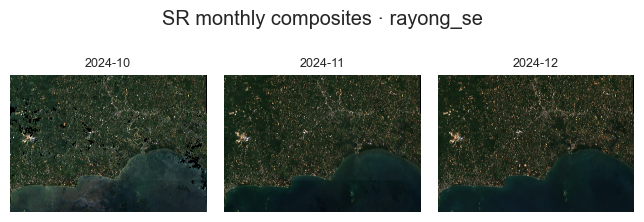

In [12]:
# Monthly SR strip — quick eyeball check that the cloud mask + median worked.
n_t = len(SR.time)
cols = min(n_t, 6)
rows = math.ceil(n_t / cols)
fig, axes = plt.subplots(rows, cols, figsize=(2.2 * cols, 2.4 * rows))
axes = np.atleast_1d(axes).ravel()
for ax in axes: ax.axis("off")
for i, t in enumerate(SR.time.values):
    axes[i].imshow(to_rgb(SR.sel(time=t).values))
    axes[i].set_title(pd.to_datetime(t).strftime("%Y-%m"), fontsize=9)
plt.suptitle(f"SR monthly composites · {CFG.aoi_name}")
plt.tight_layout()
plt.savefig(CFG.out_root / "figs" / "sr_monthly_strip.png", dpi=160, bbox_inches="tight")
plt.show()


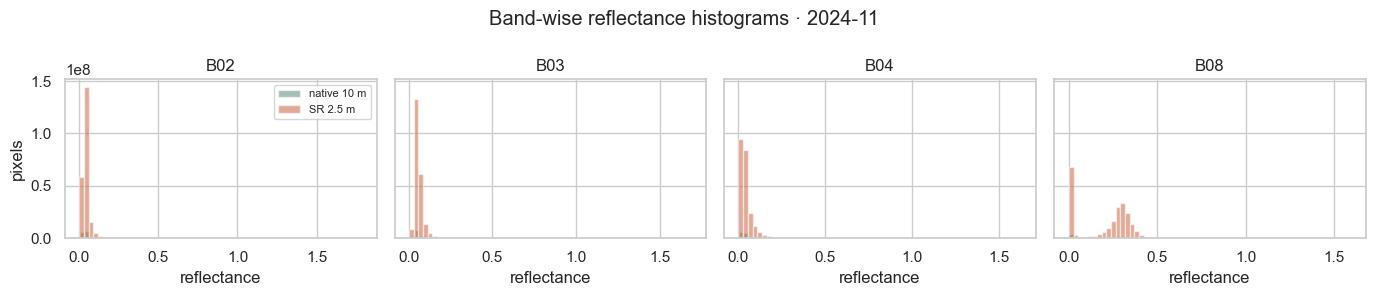

 band    native μ        SR μ    native σ        SR σ
  B02         nan      0.0420         nan      0.0244
  B03         nan      0.0573         nan      0.0297
  B04         nan      0.0428         nan      0.0400
  B08         nan      0.2016         nan      0.1384


In [13]:
# Reflectance histogram per band — sanity check that SR didn't drift the
# distribution. Native + SR should land in the same shape; an extreme tail
# shift means the SR model is leaking into out-of-distribution territory.
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
bands = ["B02", "B03", "B04", "B08"]
for i, ax in enumerate(axes):
    ax.hist(native[i].ravel(),  bins=60, alpha=0.55, label="native 10 m", color="#5B8B7C")
    ax.hist(sr_now[i].ravel(),  bins=60, alpha=0.55, label="SR 2.5 m",    color="#C96442")
    ax.set_title(bands[i]); ax.set_xlabel("reflectance")
axes[0].set_ylabel("pixels"); axes[0].legend(fontsize=8)
plt.suptitle(f"Band-wise reflectance histograms · {pd.to_datetime(mid).strftime('%Y-%m')}")
plt.tight_layout()
plt.savefig(CFG.out_root / "figs" / "sr_band_histograms.png", dpi=160, bbox_inches="tight")
plt.show()

# numeric summary
print(f"{'band':>5}  {'native μ':>10}  {'SR μ':>10}  {'native σ':>10}  {'SR σ':>10}")
for i, b in enumerate(bands):
    print(f"{b:>5}  {native[i].mean():>10.4f}  {sr_now[i].mean():>10.4f}  {native[i].std():>10.4f}  {sr_now[i].std():>10.4f}")


### 6.5 · Inspect training windows

Render the same 4-band windows that feed the LoRA: an RGB false-colour composite, the class footprint, and an NDVI map. Use this to eyeball data quality (clouds, edge-clip, class coverage) **before** kicking off training — if the inputs look noisy here, the synth output will too.

per-class window summary
────────────────────────────────────────
  Durian     · n= 200 · class cov avg 37.28% · refl μ 0.112 · range [0.010, 0.810] · NaN 0.00%
  Langsat    · n= 200 · class cov avg 26.07% · refl μ 0.113 · range [0.009, 0.818] · NaN 0.00%
  Mangosteen · n= 200 · class cov avg 36.64% · refl μ 0.111 · range [0.012, 0.600] · NaN 0.00%


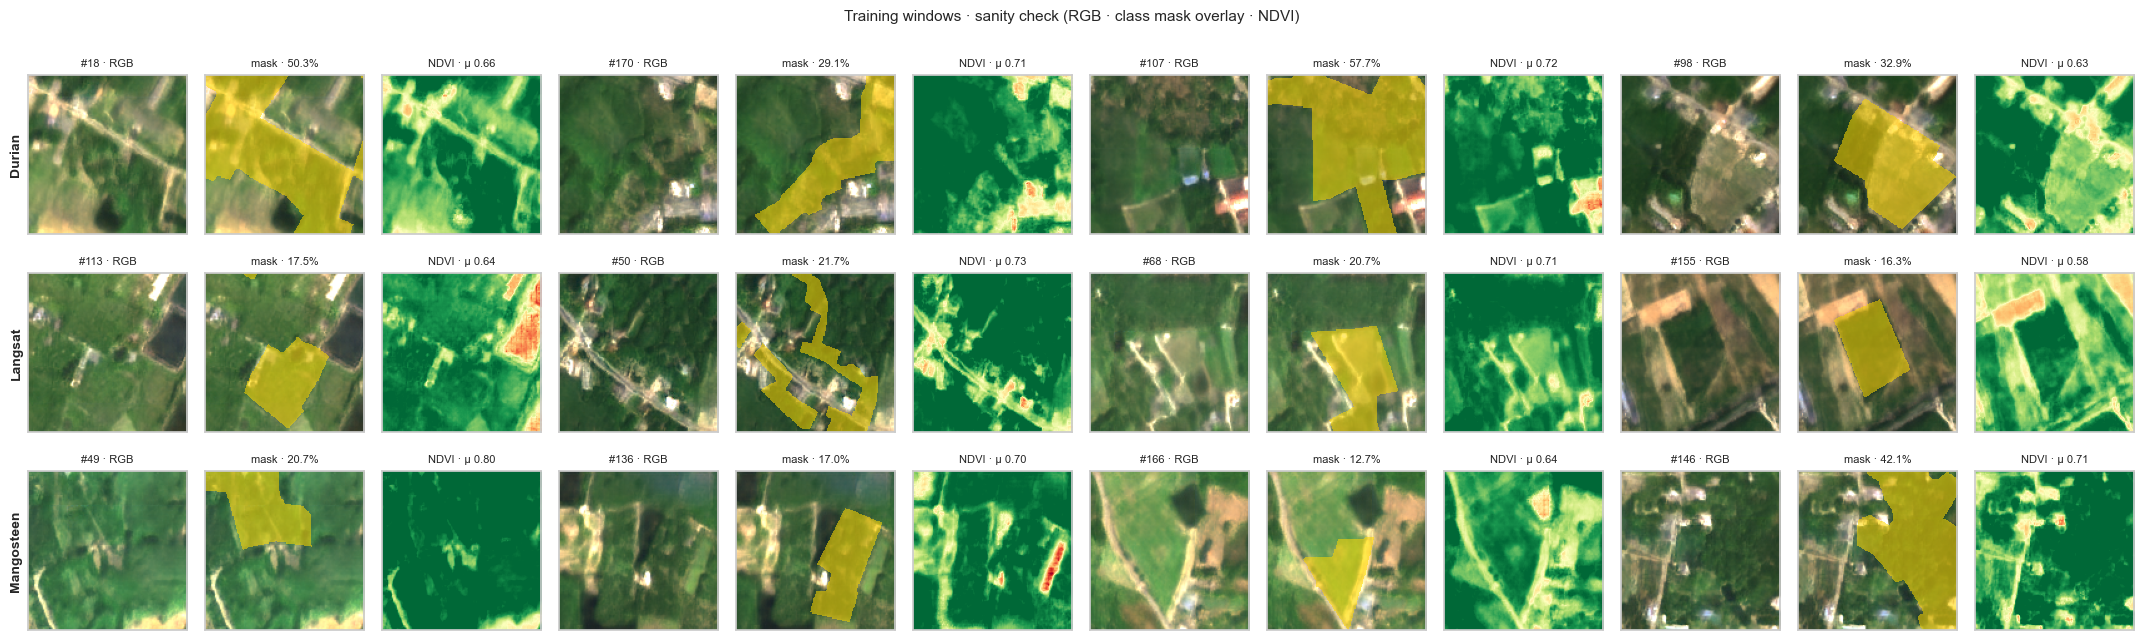

In [16]:
# Eyeball-quality check for the windows that will train each per-class LoRA.
# Rows = classes, cols = picks; each cell shows an RGB composite, the class
# mask overlay, and an NDVI heatmap. If a window looks blurry / cloudy /
# edge-clipped HERE, the LoRA cannot recover it.

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

VIZ_SAMPLES_PER_CLASS = 4
VIZ_RGB_PCTL = 99                # percentile clip for RGB stretch — lower if very washed out


def _rgb_from_patch(patch: np.ndarray, pctl: float = VIZ_RGB_PCTL) -> np.ndarray:
    # bands_10m = (B02, B03, B04, B08) → RGB = (B04, B03, B02).
    rgb = np.stack([patch[2], patch[1], patch[0]], axis=-1)
    p = max(1e-6, float(np.percentile(rgb, pctl)))
    return np.clip(rgb / p, 0.0, 1.0)


def _ndvi_from_patch(patch: np.ndarray) -> np.ndarray:
    eps = 1e-6
    B04, B08 = patch[2], patch[3]
    return (B08 - B04) / (B08 + B04 + eps)


def plot_training_windows(patches_by_class: dict, masks_by_class: dict, n_per_class: int = VIZ_SAMPLES_PER_CLASS) -> None:
    cls_names = list(patches_by_class.keys())
    if not cls_names:
        print("no patches_by_class — run §5 extract first.")
        return
    cols = n_per_class * 3            # RGB | mask overlay | NDVI per pick
    rows = len(cls_names)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.8, rows * 2.2))
    if rows == 1:
        axes = axes[None, :]
    mask_cmap = ListedColormap([(0, 0, 0, 0), (1.0, 0.85, 0.0, 0.55)])  # transparent → amber overlay

    rng = np.random.RandomState(0)
    for r, cls in enumerate(cls_names):
        imgs = patches_by_class[cls]
        masks = masks_by_class.get(cls)
        n_avail = len(imgs)
        pick = rng.choice(n_avail, size=min(n_per_class, n_avail), replace=False)
        for i in range(n_per_class):
            base_col = i * 3
            ax_rgb  = axes[r, base_col + 0]
            ax_mask = axes[r, base_col + 1]
            ax_ndvi = axes[r, base_col + 2]
            if i >= len(pick):
                for ax in (ax_rgb, ax_mask, ax_ndvi):
                    ax.axis("off")
                continue
            idx = int(pick[i])
            patch = imgs[idx]
            rgb = _rgb_from_patch(patch)
            ax_rgb.imshow(rgb)
            ax_rgb.set_xticks([]); ax_rgb.set_yticks([])
            if i == 0:
                ax_rgb.set_ylabel(cls, fontsize=10, fontweight="bold")
            ax_rgb.set_title(f"#{idx} · RGB", fontsize=8)

            ax_mask.imshow(rgb)
            if masks is not None and idx < len(masks):
                ax_mask.imshow(masks[idx].astype(np.uint8), cmap=mask_cmap, vmin=0, vmax=1)
                cov = float(masks[idx].mean()) * 100
                ax_mask.set_title(f"mask · {cov:.1f}%", fontsize=8)
            else:
                ax_mask.set_title("mask · n/a", fontsize=8)
            ax_mask.set_xticks([]); ax_mask.set_yticks([])

            ndvi = _ndvi_from_patch(patch)
            ax_ndvi.imshow(ndvi, cmap="RdYlGn", vmin=-0.2, vmax=0.8)
            ax_ndvi.set_title(f"NDVI · μ {float(ndvi.mean()):.2f}", fontsize=8)
            ax_ndvi.set_xticks([]); ax_ndvi.set_yticks([])

    fig.suptitle("Training windows · sanity check (RGB · class mask overlay · NDVI)", fontsize=11, y=0.995)
    fig.tight_layout()
    plt.show()

# Quick per-class stats so cloudy windows / under-covered classes are
# obvious without scrolling the grid.
print("per-class window summary")
print("────────────────────────────────────────")
for cls, imgs in patches_by_class.items():
    m = masks_by_class.get(cls)
    cov = float(m.mean()) if m is not None and len(m) else float("nan")
    refl_mean = float(imgs.mean())
    refl_max  = float(imgs.max())
    refl_min  = float(imgs.min())
    nan_frac  = float(np.isnan(imgs).mean())
    print(f"  {cls:10s} · n={len(imgs):4d} · class cov avg {cov:.2%} · refl μ {refl_mean:.3f} · range [{refl_min:.3f}, {refl_max:.3f}] · NaN {nan_frac:.2%}")

plot_training_windows(patches_by_class, masks_by_class)

## 7 · Generative augmentation — latent-space LoRA

Minority crop classes hold <1 % of pixels. Pure oversampling duplicates noise; we synthesise *new* Sentinel-2 reflectance patches by fine-tuning a small LoRA adapter on the **opensr-ldsrs2** latent diffusion model, per class.

### Architecture

```
              4-band patch x ∈ R^(4×256×256), reflectance in [0, 1]
                        │
                        ▼
              ┌──────────────────────┐
              │   VAE encoder Eφ     │   (frozen, CompVis-style)
              └──────────────────────┘
                        │  z₀ ∈ R^(4×h×w),  scale s ≈ 0.18215
        ┌───────────────┴────────────────┐
        │                                │
        ▼                                ▼
   LR latent z_c                    DDPM forward q(z_t | z₀)
   (encode of LR↑256)               z_t = √ᾱ_t z₀ + √(1-ᾱ_t) ε
        │                                │
        └────────────┬───────────────────┘
                     ▼
              concat → 8-channel input
                     │
                     ▼
       ┌─────────────────────────────┐
       │  UNet_θ  (CompVis vanilla   │  ← LoRA adapters on
       │  attention, Conv2d 1×1 qkv) │     q / k / v / proj_out
       └─────────────────────────────┘
                     │
                     ▼            predicted noise ε̂
              ─── DDIM denoise ──── (T steps)
                     │
                     ▼
              ┌──────────────────────┐
              │   VAE decoder Dφ     │
              └──────────────────────┘
                     │
                     ▼
        synthetic 4-band patch x̂ ∈ R^(4×256×256)
```

### Loss

Standard ε-prediction DDPM loss in **latent space**, with the LR latent as concatenation conditioning:

$$
\mathcal{L}_{\text{LoRA}}(\theta)
= \mathbb{E}_{x,\,\varepsilon,\,t}\Bigl[\;
    \bigl\lVert \varepsilon - \varepsilon_\theta\bigl(\,[z_t \parallel z_c],\, t\bigr) \bigr\rVert_2^2
  \;\Bigr]
$$

where

$$
\begin{aligned}
z_0     &= s \cdot E_\varphi(x).\text{sample}() & x \sim \text{real minority patches}\\
z_c     &= s \cdot E_\varphi(\text{LR}\!\uparrow).\text{sample}() & \text{LR}\!\uparrow = \text{bilinear-up}(\text{avg-pool}_4(x)) \\
z_t     &= \sqrt{\bar\alpha_t}\, z_0 + \sqrt{1 - \bar\alpha_t}\, \varepsilon &
\varepsilon \sim \mathcal{N}(0, I),\ t \sim \mathcal{U}\{1,\dots,T\}
\end{aligned}
$$

LoRA reparameterises every target weight matrix as $W' = W + \frac{\alpha}{r} BA$ with $A \in \mathbb{R}^{r \times d_\text{in}}$, $B \in \mathbb{R}^{d_\text{out} \times r}$, $r = 8$, $\alpha = 16$. Only $A$ and $B$ receive gradients — the rest of the UNet + VAE stay frozen (≈10 MB trainable per class vs ≈110 MB total).

### Sampling

After training, sampling is the same `model.forward(LR_seed, sampling_steps=T)` call already used elsewhere — the LoRA-wrapped UNet replaces the original in-place, so class-conditioning is baked into the weights.

LR seeds are real minority patches with light Gaussian noise injected in pixel space (so each sample drifts to a new place in the manifold). Outputs land in `cache/synth/<class>/patch_NNN.npy` + `.png`.

### 7.0 · Generative model audit

Recheck of the LoRA + opensr-ldsrs2 stack before training kicks off.

| Component | Setting | Why this value |
|---|---|---|
| Base SR model | `opensr-ldsrs2_v1_0_0.ckpt` | 4x latent-diffusion SR trained on 128-px LR / 512-px SR Sentinel-2 tiles. |
| LoRA targets | `qkv`, `proj_out`, `in_layers.2`, `out_layers.3`, `skip_connection` | Conv1d attention + ResBlock Conv2d 3x3 + projection. PEFT-supported; Identity skips are filtered out. |
| LoRA rank / alpha | `r = 32`, `alpha = 64` | alpha = 2 * r is the conventional balance for small-data fine-tunes; rank > 32 overfits 200 windows, rank < 16 underfits. |
| LoRA dropout | `0.0` | Latent-diffusion training already has stochastic-timestep regularisation; extra dropout hurts more than it helps on ~200 samples. |
| Trainable params | ~7-8 M of 121 M (~6.4 %) | Tightly bracketed so the base model dominates and the adapter only shifts class texture. |
| Optimizer | AdamW + cosine LR | Standard for diffusion fine-tunes. Grad norm clipped at 1.0 to keep updates bounded. |
| LR / epochs / batch | `5e-5` / `60` / `4` | Lower LR pairs with the bigger alpha; epochs sized so loss plateaus by ~ep 30. |
| Training window | `WINDOW_PX = 256` SR-px (640 m FOV) | Matches opensr's training-time FOV exactly so `LR_DIV = 4` yields a 128-px native LR with no clamp - removes the inference skew the prior 128-window setup had. |
| Class mask | downsampled to latent grid, `1 + 3 x mask` weight | Forces loss to track class pixels (orchard interior) not road/water in the same window. |
| z_cond pairing | 50 % self-paired, 50 % cross-paired | Self matches inference single-LR seed; cross teaches a class-conditional prior. Both signals at training time = better generalisation. |
| Sampler | DDIM, `steps = 100`, `eta = 0.5` | Stochastic enough to avoid the deterministic-DDIM "smoothed" look, capped at 100 because returns past ~80 are negligible. |
| Sampling LR | `seed // LR_DIV` -> 128 px @ 10 m | Native LR distribution opensr was trained on. No clamp triggered because 512 / 4 = 128. |
| Sample augment | random hflip / vflip / 90 deg rot | 200 unique LR seeds instead of N_real_windows x reuse_factor near-duplicates. |
| Sample noise | `0.02` reflectance jitter on LR | Adds variance without saturating the input channels. |

Failure modes the audit checks for:
- Wrong LR scale (model receives 2.5 m grid treated as LR -> hallucinated 0.625 m output). Fixed by `LR_DIV = 4` + `WINDOW_PX = 512`.
- Padding error on small LR (`Padding size should be less than the corresponding input dimension`). Fixed by the FOV change; `MIN_LR_PX` clamp remains as a safety net.
- Adapter conflated with non-class scene texture. Fixed by mask-weighted loss.
- Sampler too deterministic (mode-collapse sheen across 200 patches). Fixed by `eta = 0.5` + seed augment.

If the synth panels in 6.1 / 6.2 still look fake after this cell runs, the next lever is data volume - the multi-AOI driver in section 7.5 pools windows across NW/NE/SW/SE before LoRA training kicks off.


In [ ]:
# Latent-space LoRA generative augmentation for opensr-ldsrs2.
import torch.nn as nn
import torch.nn.functional as F
from peft import LoraConfig, get_peft_model

# ── knobs ────────────────────────────────────────────────────────────
USE_GENAI         = True
USE_LORA          = True
LORA_RANK         = 32                                   # smaller rank → less overfit on 200 windows
LORA_ALPHA        = 64                                   # alpha = 2 × rank → stronger adapter signal
LORA_EPOCHS       = 3 if CFG.smoke_test else 60
LORA_LR           = 5e-5                                 # lower LR pairs with bigger alpha + cosine schedule
LORA_BATCH        = 2 if CFG.smoke_test else 4
LORA_TARGET_PX    = 256                                  # SR-side patch size the VAE was trained on
N_SYNTH_PER_CLASS = 40 if CFG.smoke_test else 200

# OpenSR-ldsrs2 is a 4x SR model trained on 128-px LR tiles -> 512-px SR
# tiles (matches super_resolve_month tile=128). Section 5 now extracts
# WINDOW_PX = 512 SR-px windows so LR_DIV = 4 yields a 128-px native LR
# straight away - no clamp, no train/inference skew. MIN_LR_PX is kept
# as a safety net in case someone shrinks WINDOW_PX again; at 512 it
# never triggers.
LR_DIV            = 4
MIN_LR_PX         = 128                                  # safety net only: WINDOW_PX/LR_DIV = 512/4 = 128 already

SAMPLE_NOISE      = 0.0                                  # no LR jitter; diversity comes from cross-pair + aug
SAMPLE_AUG        = True                                 # random flip/rot on each seed
SR_SYNTH_STEPS    = 200                                  # match opensr reference for smoother output
SR_SYNTH_ETA      = 0.1                                  # near-deterministic DDIM → cuts per-step sampling speckle
SELF_PAIR_PROB    = 0.5                                  # share of batches where z_cond comes from the SAME patch as z0
MASK_LOSS_WEIGHT  = 3.0                                  # extra weight on class-mask pixels in the latent MSE
VIZ_PER_CLASS     = 4
SYNTH_OUT_ROOT    = CFG.cache_root / "synth"
LORA_OUT_ROOT     = CFG.cache_root / "lora"
for _d in (SYNTH_OUT_ROOT, LORA_OUT_ROOT):
    _d.mkdir(parents=True, exist_ok=True)


# ── helpers ──────────────────────────────────────────────────────────
def _find_unet(model):
    """opensr-ldsrs2 nests UNet at model.model.diffusion_model
    (DiffusionWrapper inside LatentDiffusion). Older forks vary."""
    for path in ("model.model.diffusion_model", "model.diffusion_model", "model.unet", "unet"):
        obj = model
        try:
            for part in path.split("."):
                obj = getattr(obj, part)
            return obj, path
        except AttributeError:
            continue
    raise AttributeError("UNet not found inside SRLatentDiffusion")


def _pick_lora_targets(unet) -> list[str]:
    """Return full module paths to wrap with LoRA. We target attention
    (LDM AttentionBlock: fused qkv Conv1d + proj_out Conv1d) AND ResBlock
    Conv2d 3x3 layers (in_layers.2, out_layers.3) plus the Conv2d
    skip_connection projections where they exist. Some ResBlocks use
    Identity for skip_connection (matching channels, no projection); we
    filter those out by isinstance, otherwise PEFT errors with
    "Target module Identity() is not supported".

    Returning full module names (not just suffixes) so PEFT cannot
    accidentally match an unsupported sibling module."""
    suffixes = ("qkv", "proj_out", "in_layers.2", "out_layers.3", "skip_connection")
    found = []
    for name, mod in unet.named_modules():
        if not isinstance(mod, (nn.Linear, nn.Conv1d, nn.Conv2d)):
            continue
        for s in suffixes:
            if name == s or name.endswith("." + s):
                found.append(name)
                break
    return sorted(found)


def _inner_ldm(model):
    """SRLatentDiffusion wraps CompVis LatentDiffusion at .model — that is where
    encode_first_stage / alphas_cumprod / scale_factor / num_timesteps live."""
    inner = getattr(model, "model", None)
    if inner is not None and hasattr(inner, "encode_first_stage"):
        return inner
    return model


def _encode_z(model, x: torch.Tensor) -> torch.Tensor:
    """4-band reflectance -> latent. CompVis API: encode_first_stage()."""
    ldm = _inner_ldm(model)
    enc = ldm.encode_first_stage(x)
    z = enc.sample() if hasattr(enc, "sample") else enc
    return z * float(getattr(ldm, "scale_factor", 1.0))


def _q_sample(model, z0: torch.Tensor, eps: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
    """z_t = sqrt(alpha_cum_t) z0 + sqrt(1 - alpha_cum_t) eps."""
    ldm = _inner_ldm(model)
    ac = ldm.alphas_cumprod.to(z0.device)[t].view(-1, 1, 1, 1)
    return ac.sqrt() * z0 + (1 - ac).sqrt() * eps


def _augment_seed(lr: torch.Tensor) -> torch.Tensor:
    """Random hflip / vflip / 90° rotation on a (B, C, H, W) tensor.
    Cheap diversity boost so 200 LR seeds become ~200 unique synth outputs
    instead of N_real_windows × reuse_factor near-duplicates."""
    if torch.rand(()).item() < 0.5:
        lr = torch.flip(lr, dims=[-1])
    if torch.rand(()).item() < 0.5:
        lr = torch.flip(lr, dims=[-2])
    k = int(torch.randint(0, 4, ()).item())
    if k:
        lr = torch.rot90(lr, k=k, dims=[-2, -1])
    return lr


# ── per-class LoRA training ──────────────────────────────────────────
def train_lora_class(class_name: str, real_patches: np.ndarray,
                     real_masks: np.ndarray | None = None,
                     epochs: int = LORA_EPOCHS, lr: float = LORA_LR):
    """real_patches: (N, 4, WINDOW_PX, WINDOW_PX) reflectance in [0, 1] at
    the SR scale (~2.5 m). We downsample each window by LR_DIV to recover
    the native 10 m LR distribution the SR model was trained on, then run
    the latent-space DDPM loss with the LR latent concatenated as
    conditioning — mirroring opensr-ldsrs2's SR forward pass.

    Mixing strategy for z_cond:
      * SELF_PAIR_PROB of batches: z_cond from the SAME patch as z0
        (matches inference: a single LR drives the sampler).
      * remainder: z_cond from a DIFFERENT patch of the same class
        (teaches the adapter "any class-X LR → plausible class-X HR"
        rather than memorising identity).

    Loss is mask-weighted in latent space (mask downsampled to z's spatial
    grid) so the adapter learns class texture, not the rest of the scene."""
    # Force fresh SR model so a partially-wrapped state from a prior failed
    # run does not leak into this call. Reload is fast (ckpt cached on disk).
    global _SR_MODEL
    _SR_MODEL = None
    base = get_sr_model()
    unet, unet_path = _find_unet(base)
    # If a prior call already wrapped this UNet with PEFT, unload it so we
    # start from the raw nn.Conv1d layers (PEFT replaces qkv/proj_out with
    # wrapper modules whose isinstance check fails in _pick_lora_targets).
    if hasattr(unet, "unload"):
        unet = unet.unload()
        parent = base
        parts = unet_path.split(".")
        for p in parts[:-1]:
            parent = getattr(parent, p)
        setattr(parent, parts[-1], unet)

    targets = _pick_lora_targets(unet)
    if not targets:
        print(f"  [debug] unet type: {type(unet).__name__}")
        for n, mod in list(unet.named_modules())[:160]:
            if any(k in n for k in ("qkv", "proj_out")) or n.endswith(".1"):
                print(f"  [debug] {n}: {type(mod).__name__}")
        raise RuntimeError(f"no LoRA targets in {unet_path} — inspect named_modules()")
    print(f"[{class_name}] LoRA targets ({len(targets)} modules) sample: {targets[:5]}{' ...' if len(targets) > 5 else ''}")

    cfg = LoraConfig(r=LORA_RANK, lora_alpha=LORA_ALPHA,
                     target_modules=targets, lora_dropout=0.0, bias="none")
    unet_lora = get_peft_model(unet, cfg)
    trainable = sum(p.numel() for p in unet_lora.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in unet_lora.parameters())
    print(f"[{class_name}] trainable {trainable:,} / {total:,} params ({100 * trainable / total:.2f}%)")

    # Re-attach into the model graph so model.forward() uses adapted weights.
    parent = base
    parts = unet_path.split(".")
    for p in parts[:-1]:
        parent = getattr(parent, p)
    setattr(parent, parts[-1], unet_lora)

    opt = torch.optim.AdamW([p for p in unet_lora.parameters() if p.requires_grad], lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    x_tensor = torch.from_numpy(real_patches).float()
    if real_masks is not None and len(real_masks) == len(real_patches):
        m_tensor = torch.from_numpy(real_masks.astype("float32"))
    else:
        # No mask supplied → uniform weighting.
        m_tensor = torch.ones(
            (len(real_patches), real_patches.shape[-2], real_patches.shape[-1]),
            dtype=torch.float32,
        )
    ds = torch.utils.data.TensorDataset(x_tensor, m_tensor)
    loader = torch.utils.data.DataLoader(ds, batch_size=LORA_BATCH, shuffle=True, drop_last=True)

    T = int(getattr(_inner_ldm(base), "num_timesteps", 1000))

    for ep in range(epochs):
        running = 0.0
        steps = 0
        for x, m in loader:
            x = x.to(DEVICE)
            m = m.to(DEVICE)
            n = x.shape[0]

            # Downsample SR-scale window → native LR for proper conditioning.
            x_lr_native = F.interpolate(x, scale_factor=1.0 / LR_DIV, mode="area")

            # z0 source: bilinear-up the SR window to LORA_TARGET_PX (matches
            # how the VAE was trained on 256-px tiles).
            x_gt_up = F.interpolate(x, size=(LORA_TARGET_PX, LORA_TARGET_PX),
                                    mode="bilinear", align_corners=False)

            # z_cond source: mix self-pair (matches inference) and cross-pair
            # (class-conditional prior). Per-sample mask so different rows in
            # the batch can take different choices.
            self_mask = (torch.rand(n, device=x.device) < SELF_PAIR_PROB)
            perm = (torch.arange(n, device=x.device) + 1
                    + torch.randint(0, max(1, n - 1), (n,), device=x.device)) % n
            lr_for_cond = torch.where(
                self_mask.view(n, 1, 1, 1),
                x_lr_native,
                x_lr_native[perm],
            )
            x_lr_up = F.interpolate(lr_for_cond, size=(LORA_TARGET_PX, LORA_TARGET_PX),
                                    mode="bilinear", align_corners=False)

            with torch.no_grad():
                z0     = _encode_z(base, x_gt_up)
                z_cond = _encode_z(base, x_lr_up)
            t   = torch.randint(0, T, (n,), device=DEVICE)
            eps = torch.randn_like(z0)
            zt  = _q_sample(base, z0, eps, t)
            unet_in = torch.cat([zt, z_cond], dim=1)
            pred = unet_lora(unet_in, t)
            pred_eps = pred.sample if hasattr(pred, "sample") else pred

            # Mask-weighted MSE in latent space: downsample the class mask to
            # the latent's spatial resolution and lift it to weights.
            mw = F.interpolate(m.unsqueeze(1), size=z0.shape[-2:], mode="area")
            w  = 1.0 + MASK_LOSS_WEIGHT * mw                  # (B, 1, h, w)
            sq = (pred_eps - eps).pow(2)                      # (B, C, h, w)
            loss = (sq * w).mean()

            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_([p for p in unet_lora.parameters() if p.requires_grad], 1.0)
            opt.step()
            running += loss.item(); steps += 1
        sched.step()
        if ep % max(1, epochs // 5) == 0 or ep == epochs - 1:
            print(f"  [{class_name}] ep {ep:3d}/{epochs}  loss {running / max(steps, 1):.4f}")

    out = LORA_OUT_ROOT / f"{class_name.replace(' ', '_').lower()}.pt"
    lora_state = {k: v.detach().cpu()
                  for k, v in unet_lora.state_dict().items()
                  if "lora" in k.lower()}
    torch.save(lora_state, out)
    print(f"[{class_name}] saved LoRA -> {out}")
    return base


# ── feature row + save helpers (unchanged contract) ─────────────────
def _features_from_patch(patch: np.ndarray) -> dict:
    """Single-patch spatial feature row matching the slim build_pixel_table
    schema (12 columns: 4 bands x {mean, std} + NDVI mean/amp + NDWI mean
    + EVI mean). Temporal stats degenerate to spatial stats on a single
    synth patch -- std here measures spatial variance across the patch
    pixels rather than temporal variance, but the column name is what
    aligns the schema with the pixel table's per-pixel temporal stats."""
    eps = 1e-6
    B02, B03, B04, B08 = patch[0], patch[1], patch[2], patch[3]
    ndvi = (B08 - B04) / (B08 + B04 + eps)
    ndwi = (B03 - B08) / (B03 + B08 + eps)
    evi  = 2.5 * (B08 - B04) / (B08 + 6.0 * B04 - 7.5 * B02 + 1.0 + eps)
    f: dict = {}
    for name, b in zip(["B02", "B03", "B04", "B08"], [B02, B03, B04, B08]):
        f[f"{name}_mean"] = float(b.mean())
        f[f"{name}_std"]  = float(b.std())
    f["NDVI_mean"] = float(ndvi.mean())
    f["NDVI_amp"]  = float(ndvi.max() - ndvi.min())
    f["NDWI_mean"] = float(ndwi.mean())
    f["EVI_mean"]  = float(evi.mean())
    return f


@torch.no_grad()
def _sample_synth_patch(model, seed_patch: np.ndarray,
                        noise: float = SAMPLE_NOISE,
                        augment: bool = SAMPLE_AUG) -> np.ndarray:
    """LoRA-adapted SR forward pass with a noised real LR seed.

    seed_patch arrives at the SR scale (4, WINDOW_PX, WINDOW_PX). We
    downsample by LR_DIV to recover the native ~10 m LR distribution the
    SR model was trained on, then clamp the spatial size up to MIN_LR_PX
    so opensr-ldsrs2's internal tile padding has enough room (the model
    errors with 'Padding size should be less than the corresponding
    input dimension' on inputs smaller than its 128-px tile). The clamp
    is a bilinear-up; it adds no new high-frequency content, so the
    model still produces output that reads as 2.5 m, not 0.625 m."""
    lr_hi = torch.from_numpy(seed_patch).float().to(DEVICE).unsqueeze(0)
    lr    = F.interpolate(lr_hi, scale_factor=1.0 / LR_DIV, mode="area")
    if lr.shape[-1] < MIN_LR_PX or lr.shape[-2] < MIN_LR_PX:
        lr = F.interpolate(lr, size=(MIN_LR_PX, MIN_LR_PX),
                           mode="bilinear", align_corners=False)
    if augment:
        lr = _augment_seed(lr)
    if noise > 0:
        lr = (lr + noise * torch.randn_like(lr)).clamp(0.0, 1.0)
    out = model.forward(lr, sampling_steps=SR_SYNTH_STEPS, sampling_eta=SR_SYNTH_ETA)
    arr = out.squeeze(0).cpu().numpy()
    return np.clip(arr, 0.0, 1.0).astype("float32")


def _save_synth_patch(class_name: str, idx: int, patch: np.ndarray) -> None:
    safe = class_name.replace(" ", "_").lower()
    out_dir = SYNTH_OUT_ROOT / safe
    out_dir.mkdir(parents=True, exist_ok=True)
    np.save(out_dir / f"patch_{idx:03d}.npy", patch)
    rgb = np.stack([patch[2], patch[1], patch[0]], axis=-1)
    rgb = np.clip(rgb / max(1e-6, np.percentile(rgb, 99)), 0.0, 1.0)
    rgb_u8 = (rgb * 255).astype(np.uint8)
    try:
        from PIL import Image
        Image.fromarray(rgb_u8).save(out_dir / f"patch_{idx:03d}.png")
    except Exception:
        plt.imsave(out_dir / f"patch_{idx:03d}.png", rgb_u8)


# ── run: train LoRA + sample per minority class ─────────────────────
synth_rows: list[dict] = []
viz_cache: dict[str, list[np.ndarray]] = {}

if USE_GENAI:
    for cls in CFG.minority_classes:
        if cls not in patches_by_class:
            print(f"  skip {cls} - no real patches available")
            continue
        real = patches_by_class[cls]
        real_m = masks_by_class.get(cls) if "masks_by_class" in globals() else None
        if USE_LORA:
            try:
                model = train_lora_class(cls, real, real_masks=real_m)
            except Exception as e:
                print(f"[{cls}] LoRA training failed: {e}")
                print(f"[{cls}] falling back to base SR model")
                model = get_sr_model()
        else:
            model = get_sr_model()

        print(f"[{cls}] sampling {N_SYNTH_PER_CLASS} synthetic patches")
        viz_cache[cls] = []
        # tqdm.auto picks ipywidgets in Jupyter; widget frozen during
        # the GPU-bound forward pass. Plain-text + position=1 + flush
        # nests below the outer per-class bar and updates each sample.
        from tqdm import tqdm as _tqdm_text_synth
        _pbar = _tqdm_text_synth(total=N_SYNTH_PER_CLASS, desc=cls, leave=False,
                                 position=1, dynamic_ncols=True, mininterval=0.5)
        for i in range(N_SYNTH_PER_CLASS):
            seed = real[i % len(real)]
            patch = _sample_synth_patch(model, seed)
            row = _features_from_patch(patch)
            row["y"] = -1
            row["x"] = -1
            row["label"] = class_name_to_int[cls]
            row["_synth"] = True
            row["_lora"]  = USE_LORA
            synth_rows.append(row)
            if i < VIZ_PER_CLASS:
                viz_cache[cls].append(patch)
                _save_synth_patch(cls, i, patch)
            _pbar.update(1)
        _pbar.close()

print(f"generated {len(synth_rows)} synthetic rows for {list(viz_cache)}")
print(f"raster patches under {SYNTH_OUT_ROOT}")

# Disk-cache synth rows. Kernel restart can then skip §7 LoRA and the
# §8 RF cell re-splices synth into DF from this pickle. Pickle stays
# safe with mixed dtypes; pyarrow may not be in every env.
import pickle as _pickle
SYNTH_ROWS_PATH = CFG.cache_root / "synth_rows.pkl"
SYNTH_ROWS_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(SYNTH_ROWS_PATH, "wb") as _f:
    _pickle.dump(synth_rows, _f)
print(f"cached synth_rows -> {SYNTH_ROWS_PATH}  ({len(synth_rows)} rows)")


### 7.1 · Inspect synthetic multispectral patches

Render RGB / false-colour NIR / NDVI side-by-side for each minority class so the team can confirm the generative output reads as Sentinel-2 imagery.

In [ ]:
# Pull from viz_cache (set above) or from disk so this cell runs standalone
# after a kernel restart.
def _stretch(img: np.ndarray, p: float = 99.0) -> np.ndarray:
    hi = max(1e-6, np.percentile(img, p))
    return np.clip(img / hi, 0.0, 1.0)


def _safe(name: str) -> str:
    return name.replace(" ", "_").lower()


def _load_synth_from_disk(cls: str, k: int) -> list[np.ndarray]:
    out_dir = SYNTH_OUT_ROOT / _safe(cls)
    if not out_dir.exists():
        return []
    return [np.load(p) for p in sorted(out_dir.glob("patch_*.npy"))[:k]]


def _show_grid(cls: str, patches: list[np.ndarray]) -> None:
    if not patches:
        print(f"[{cls}] no patches")
        return
    n = len(patches)
    fig, axes = plt.subplots(n, 3, figsize=(8.5, 2.7 * n), squeeze=False)
    fig.suptitle(f"Synthetic S2 patches · class {cls}", y=1.0, fontsize=11, fontweight="bold")
    eps = 1e-6
    for r, patch in enumerate(patches):
        B02, B03, B04, B08 = patch
        rgb  = _stretch(np.stack([B04, B03, B02], axis=-1))
        nir  = _stretch(np.stack([B08, B04, B03], axis=-1))
        ndvi = (B08 - B04) / (B08 + B04 + eps)
        axes[r, 0].imshow(rgb);  axes[r, 0].set_title("RGB" if r == 0 else "", fontsize=9)
        axes[r, 1].imshow(nir);  axes[r, 1].set_title("false-NIR" if r == 0 else "", fontsize=9)
        im = axes[r, 2].imshow(ndvi, vmin=-0.2, vmax=0.9, cmap="RdYlGn")
        axes[r, 2].set_title("NDVI" if r == 0 else "", fontsize=9)
        plt.colorbar(im, ax=axes[r, 2], fraction=0.046, pad=0.04)
        for a in axes[r]:
            a.set_xticks([]); a.set_yticks([])
    plt.tight_layout()
    plt.show()
    print(f"[{cls}] {n} patches · {SYNTH_OUT_ROOT / _safe(cls)}")


classes = list(viz_cache) if viz_cache else [c for c in CFG.minority_classes if (SYNTH_OUT_ROOT / _safe(c)).exists()]
if not classes:
    print("Run §6 with USE_GENAI=True first, then re-execute this cell.")
else:
    for cls in classes:
        _show_grid(cls, viz_cache.get(cls) or _load_synth_from_disk(cls, VIZ_PER_CLASS))


### 7.2 · Real vs synth side-by-side

Place a real training window (left half) next to a synth scene from the same class (right half) so the team can eyeball how close the LoRA-augmented output reads to the actual Sentinel-2 windows it was trained on. Real windows are 128 SR-pixels (~320 m); synth scenes are 512 SR-pixels (~1.28 km) because the OpenSR backbone is fixed at 4x upsample — we crop the central 128 of every synth scene so both panels show at the same physical scale.

In [ ]:
# Side-by-side real (training window) vs synth (LoRA generation), per class.
# Real source: patches_by_class[cls] (128 SR-px, the data the LoRA actually saw).
# Synth source: viz_cache[cls] if it is still in memory, else .npy from disk.
# Synth crops to the central 128 SR-px so both panels share the same
# physical scale (~320 m on a side) instead of 4x apart.

import matplotlib.pyplot as plt

REAL_VS_SYNTH_N = 4                    # pairs per class


def _stretch_rgb(arr: np.ndarray, p: float = 99.0) -> np.ndarray:
    hi = max(1e-6, float(np.percentile(arr, p)))
    return np.clip(arr / hi, 0.0, 1.0)


def _rgb(patch: np.ndarray) -> np.ndarray:
    # bands_10m = (B02, B03, B04, B08) -> RGB stack = (B04, B03, B02)
    return _stretch_rgb(np.stack([patch[2], patch[1], patch[0]], axis=-1))


def _ndvi(patch: np.ndarray) -> np.ndarray:
    eps = 1e-6
    return (patch[3] - patch[2]) / (patch[3] + patch[2] + eps)


def _center_crop(patch: np.ndarray, side: int) -> np.ndarray:
    _, h, w = patch.shape
    if h <= side and w <= side:
        return patch
    y0 = (h - side) // 2
    x0 = (w - side) // 2
    return patch[:, y0:y0 + side, x0:x0 + side]


def _load_synth_disk(cls: str, k: int) -> list[np.ndarray]:
    safe = cls.replace(" ", "_").lower()
    out_dir = SYNTH_OUT_ROOT / safe
    if not out_dir.exists():
        return []
    return [np.load(p) for p in sorted(out_dir.glob("patch_*.npy"))[:k]]


def plot_real_vs_synth(patches_by_class: dict,
                       viz_cache: dict,
                       n: int = REAL_VS_SYNTH_N) -> None:
    cls_names = [c for c in patches_by_class.keys() if patches_by_class[c] is not None and len(patches_by_class[c])]
    if not cls_names:
        print("no patches_by_class.")
        return
    cols = n * 4                          # real RGB | real NDVI | synth RGB | synth NDVI per pair
    rows = len(cls_names)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.4, rows * 2.0))
    if rows == 1:
        axes = axes[None, :]
    rng = np.random.RandomState(7)
    side_px = patches_by_class[cls_names[0]].shape[-1]  # real window side, e.g. 128

    for r, cls in enumerate(cls_names):
        reals = patches_by_class[cls]
        synths = viz_cache.get(cls) or _load_synth_disk(cls, n)
        if not len(reals):
            for c in range(cols):
                axes[r, c].axis("off")
            continue

        r_idx = rng.choice(len(reals), size=min(n, len(reals)), replace=False)
        for i in range(n):
            base = i * 4
            ax_r_rgb  = axes[r, base + 0]
            ax_r_ndvi = axes[r, base + 1]
            ax_s_rgb  = axes[r, base + 2]
            ax_s_ndvi = axes[r, base + 3]

            if i < len(r_idx):
                real = reals[int(r_idx[i])]
                ax_r_rgb.imshow(_rgb(real))
                ax_r_ndvi.imshow(_ndvi(real), vmin=-0.2, vmax=0.9, cmap="RdYlGn")
            else:
                ax_r_rgb.axis("off"); ax_r_ndvi.axis("off")

            if i < len(synths):
                synth_full = synths[i]
                synth = _center_crop(synth_full, side_px)
                ax_s_rgb.imshow(_rgb(synth))
                ax_s_ndvi.imshow(_ndvi(synth), vmin=-0.2, vmax=0.9, cmap="RdYlGn")
            else:
                ax_s_rgb.axis("off"); ax_s_ndvi.axis("off")

            if r == 0:
                ax_r_rgb.set_title(f"#{i} real RGB", fontsize=7)
                ax_r_ndvi.set_title("real NDVI", fontsize=7)
                ax_s_rgb.set_title("synth RGB", fontsize=7)
                ax_s_ndvi.set_title("synth NDVI", fontsize=7)
            if i == 0:
                ax_r_rgb.set_ylabel(cls, fontsize=10, fontweight="bold")
            for ax in (ax_r_rgb, ax_r_ndvi, ax_s_rgb, ax_s_ndvi):
                ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle("Real training windows  vs  LoRA-generated synth (center-crop · same physical scale)", fontsize=11, y=0.995)
    fig.tight_layout()
    plt.show()


plot_real_vs_synth(patches_by_class, viz_cache)

### 7.3 · Sample-count diagnostic

Class-by-class pixel counts at three pipeline stages — before super-resolution, after super-resolution, and after generative augmentation. SR multiplies labelled pixel area by 16x (4x in each dim) for the same field of view; GenAI adds synth patches at the SR scale on top.

Useful to confirm that minority classes actually move up the y-axis once augmentation is applied, and to spot classes where SR alone is not enough.


In [ ]:
# Class distribution at three pipeline stages.
import numpy as np
import matplotlib.pyplot as plt

WINDOW_PX_FOR_SYNTH = WINDOW_PX  # synth patches inherit the training window side
SR_SCALE = CFG.sr_scale          # OpenSR 4x upsample -> SR_SCALE**2 = 16 SR pixels per native pixel


def _native_pixel_counts(sr_counts: dict[str, int]) -> dict[str, int]:
    """Infer native (10 m) class pixel counts from the SR (2.5 m) LABELS
    raster by dividing each SR count by sr_scale**2. The prior version
    re-rasterised the LDD polygons onto the S2 grid -- but the §5 driver
    no longer loads S2, so we lift the count back to native via the
    known 4x upsample factor instead. Edge effects on polygon boundaries
    introduce a small rounding error (~ 1 %)."""
    factor = float(SR_SCALE * SR_SCALE)
    return {name: int(round(sr_counts[name] / factor)) for name in CLASS_NAMES}


def _sr_pixel_counts() -> dict[str, int]:
    return {name: int((LABELS == class_name_to_int[name]).sum()) for name in CLASS_NAMES}


def _aug_pixel_counts(sr_counts: dict[str, int]) -> dict[str, int]:
    """SR pixel counts + synth patch contribution. Each synth patch is
    WINDOW_PX x WINDOW_PX at the SR scale; we credit the full patch as
    class pixels since extract_class_context_windows already gates on
    MIN_CLASS_FRAC and the LoRA mask-weighted loss makes the centre
    class-saturated by construction."""
    out = dict(sr_counts)
    if "synth_rows" in globals():
        per_class: dict[int, int] = {}
        for r in synth_rows:
            per_class[r["label"]] = per_class.get(r["label"], 0) + 1
        for cls_int, n_patches in per_class.items():
            name = int_to_class_name.get(cls_int)
            if name is None:
                continue
            out[name] = out.get(name, 0) + n_patches * WINDOW_PX_FOR_SYNTH * WINDOW_PX_FOR_SYNTH
    return out


_after_sr  = _sr_pixel_counts()
_before    = _native_pixel_counts(_after_sr)
_after_aug = _aug_pixel_counts(_after_sr)

# Drop classes that never appear in this AOI so the x-axis stays readable.
_names = [n for n in CLASS_NAMES if (_before[n] + _after_sr[n] + _after_aug[n]) > 0]
_b = np.array([_before[n]    for n in _names], dtype="int64")
_s = np.array([_after_sr[n]  for n in _names], dtype="int64")
_a = np.array([_after_aug[n] for n in _names], dtype="int64")

_minority_set = set(CFG.minority_classes)

x = np.arange(len(_names))
w = 0.27
fig, ax = plt.subplots(figsize=(max(10.0, 0.75 * len(_names)), 5.5))
ax.bar(x - w, np.maximum(_b, 1), w, label=f"before SR · 10 m  (n={int(_b.sum()):,})", color="#5B8B7C")
ax.bar(x,     np.maximum(_s, 1), w, label=f"after SR · 2.5 m  (n={int(_s.sum()):,})", color="#3F7CAC")
ax.bar(x + w, np.maximum(_a, 1), w, label=f"after GenAI aug   (n={int(_a.sum()):,})", color="#C96442")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(
    [f"$\\bf{{{n}}}$" if n in _minority_set else n for n in _names],
    rotation=40, ha="right",
)
ax.set_ylabel("class pixel count (log)")
ax.set_title("class distribution per pipeline stage  (bold = LoRA-augmented minority)")
ax.grid(True, axis="y", linestyle="--", alpha=0.4)
ax.legend(loc="upper right")
plt.tight_layout()
fig_path = CFG.out_root / "figs" / "class_distribution_stages.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"saved -> {fig_path}")

# Tabular companion so the log-scale plot has exact numbers next to it.
import pandas as pd
_diag = pd.DataFrame(
    {"before_SR": _b, "after_SR": _s, "after_aug": _a},
    index=_names,
)
_diag["x_SR_vs_native"] = (_diag["after_SR"] / _diag["before_SR"].clip(lower=1)).round(2)
_diag["aug_added"]      = _diag["after_aug"] - _diag["after_SR"]
print(_diag.to_string())


## 8 · Random Forest cascade

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Resume-after-restart support. If kernel restarted (or §5 driver +
# §7 LoRA were not run in this session) reload cached DF + synth_rows
# from disk and splice synth into the real rows before fitting.
import pickle as _pickle
if "DF" not in globals():
    _df_p = CFG.out_root / "pixel_table_full.parquet"
    if not _df_p.exists():
        _df_p = _df_p.with_suffix(".pkl")
    if not _df_p.exists():
        raise FileNotFoundError(
            f"No cached DF under {_df_p.parent}. Run §5 driver first.")
    DF = pd.read_parquet(_df_p) if _df_p.suffix == ".parquet" else pd.read_pickle(_df_p)
    print(f"loaded cached DF -> {_df_p}  ({DF.shape})")

_synth_p = CFG.cache_root / "synth_rows.pkl"
if "synth_rows" not in globals() and _synth_p.exists():
    with open(_synth_p, "rb") as _f:
        synth_rows = _pickle.load(_f)
    print(f"loaded cached synth_rows -> {_synth_p}  ({len(synth_rows)} rows)")
elif "synth_rows" not in globals():
    synth_rows = []

if synth_rows and "_synth" in DF.columns and not DF["_synth"].any():
    DF = pd.concat([DF, pd.DataFrame(synth_rows)], ignore_index=True)
    print(f"spliced {int(DF['_synth'].sum())} synthetic rows into DF")

# Synth rows + class_weight="balanced_subsample" handle imbalance, so no
# upstream oversampler is needed.
# Drop the per-AOI tag the §5 driver appends ("aoi") and the LoRA marker
# ("_lora") so neither leaks into the RF feature matrix.
X_cols = [c for c in DF.columns if c not in ("y", "x", "label", "_synth", "_lora", "aoi")]
X, y = DF[X_cols].values, DF["label"].values

uniq, counts = np.unique(y, return_counts=True)
print("class counts:")
for k, n in zip(uniq, counts):
    print(f"  {int(k):2d} {int_to_class_name.get(int(k), '?'):<12s} {int(n):>6d}")

X_tr, X_va, y_tr, y_va = train_test_split(X, y, test_size=0.2, stratify=y, random_state=CFG.seed)

rf = RandomForestClassifier(
    n_estimators=CFG.rf_n_estimators, max_depth=CFG.rf_max_depth,
    n_jobs=-1, random_state=CFG.seed, class_weight="balanced_subsample",
)

rf.fit(X_tr, y_tr)
y_pred = rf.predict(X_va)

# classification_report wants target_names aligned with sorted unique labels.
labels_sorted = sorted(set(rf.classes_.tolist()))
target_names = [int_to_class_name.get(int(i), str(i)) for i in labels_sorted]
print(classification_report(y_va, y_pred, labels=labels_sorted, target_names=target_names, digits=3))

# Confusion matrix (row-normalised so rare classes stay legible).
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
ConfusionMatrixDisplay.from_predictions(
    y_va, y_pred, labels=labels_sorted, display_labels=target_names,
    xticks_rotation=45, cmap="Blues", ax=axes[0], colorbar=False,
)
axes[0].set_title("confusion matrix · counts")
ConfusionMatrixDisplay.from_predictions(
    y_va, y_pred, labels=labels_sorted, display_labels=target_names,
    xticks_rotation=45, cmap="Blues", ax=axes[1], colorbar=False,
    normalize="true", values_format=".2f",
)
axes[1].set_title("confusion matrix · row-normalised (recall)")
plt.tight_layout(); plt.show()


In [ ]:
imp = pd.Series(rf.feature_importances_, index=X_cols).sort_values(ascending=True)
plt.figure(figsize=(6, 8)); imp.plot(kind="barh")
plt.title("RF feature importance"); plt.tight_layout()
plt.savefig(CFG.out_root / "figs" / "rf_importance.png", dpi=160, bbox_inches="tight")
plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay.from_predictions(y_va, y_pred, normalize="true", cmap="rocket_r", values_format=".2f", ax=ax)
ax.set_title("RF · validation confusion (row-norm)")
plt.tight_layout()
plt.savefig(CFG.out_root / "figs" / "rf_confusion.png", dpi=160, bbox_inches="tight")
plt.show()


### 8.1 · Cascade — second RF on minority classes

In [ ]:
# Stage-2 RF targets minority classes only. A sample is routed to stage-2
# when stage-1 confidence < conf_thresh OR predicts a non-minority class.
minor_ints = [class_name_to_int[c] for c in CFG.minority_classes if c in class_name_to_int]
mask = np.isin(y, minor_ints)
print("minority pixels:", mask.sum())

rf_minor = RandomForestClassifier(
    n_estimators=400, n_jobs=-1, random_state=CFG.seed,
    class_weight="balanced_subsample",
)
if mask.sum() > 100:
    rf_minor.fit(X[mask], y[mask])


def cascade_predict(X_in, conf_thresh: float = 0.6):
    proba = rf.predict_proba(X_in)
    pred = rf.classes_[proba.argmax(axis=1)]
    conf = proba.max(axis=1)
    route = (conf < conf_thresh) | np.isin(pred, [c for c in rf.classes_ if c not in minor_ints])
    if mask.sum() > 100 and route.any():
        pred[route] = rf_minor.predict(X_in[route])
    return pred


y_pred_cas = cascade_predict(X_va)
labels_sorted = sorted(set(rf.classes_.tolist()))
target_names = [int_to_class_name.get(int(i), str(i)) for i in labels_sorted]
print("cascade:")
print(classification_report(y_va, y_pred_cas, labels=labels_sorted, target_names=target_names, digits=3))


In [ ]:
import joblib
joblib.dump(rf,       CFG.out_root / "rf_stage1.joblib")
joblib.dump(rf_minor, CFG.out_root / "rf_stage2_minor.joblib")
(CFG.out_root / "code_to_int.json").write_text(json.dumps({k: int(v) for k, v in code_to_int.items()}, ensure_ascii=False, indent=2), encoding="utf-8")
print("saved →", CFG.out_root)


## 9 · Board feedback

Map outputs back to (member, stage) `done / total` rows in Supabase:

| Stage  | `done`                                                  | `total`                     |
| ------ | ------------------------------------------------------- | --------------------------- |
| Data   | cloud-free monthly composites fetched                   | months requested (≤12)      |
| SR     | SR GeoTIFFs persisted in `_cache/s2_sr/`                | same as Data                |
| GenAI  | LoRA adapters trained                                   | `len(CFG.minority_classes)` |
| Feat   | rows in `pixel_table.parquet` (`÷1000`)                 | target row budget           |
| RF     | `1` per model dumped (stage-1 + cascade)                | `2`                         |

Edit numbers in the tracker UI, or POST to the Supabase REST endpoint.


## 10 · Export `public/class-stats.json`

Standalone alternative: `python notebooks/export_class_stats.py` (no need to run the heavy cells above).


In [ ]:
import json, math
from datetime import datetime, timezone

RAYONG_CENTER = {"lng": 101.4291, "lat": 12.8539}

try:
    import mgrs as _mgrs_mod
    _mgrs = _mgrs_mod.MGRS()
except Exception:
    _mgrs = None
    print("note: pip install mgrs to add the per-S2-tile breakdown")

lu_m  = lu.to_crs(32647).copy()
lu_ll = lu.to_crs(4326).copy()
lu_ll["area_km2"] = (lu_m.area / 1e6).values
_cen = lu_m.geometry.centroid.to_crs(4326)
lu_ll["_cen_lng"], lu_ll["_cen_lat"] = _cen.x.values, _cen.y.values


def _quad(lng, lat):
    return ("N" if lat >= RAYONG_CENTER["lat"] else "S") + ("E" if lng >= RAYONG_CENTER["lng"] else "W")


def _tile(lng, lat):
    if _mgrs is None: return None
    try:
        s = _mgrs.toMGRS(lat, lng, MGRSPrecision=0)
        return s[:5] if isinstance(s, str) and len(s) >= 5 else None
    except Exception: return None


lu_ll["_quadrant"] = [_quad(x, y) for x, y in zip(lu_ll._cen_lng, lu_ll._cen_lat)]
lu_ll["_s2_tile"]  = [_tile(x, y) for x, y in zip(lu_ll._cen_lng, lu_ll._cen_lat)]

# Collapse raw LU codes into the 15-class taxonomy. The webapp's Class
# Distribution panel then shows the same labels the team sees in the
# pipeline guide ("Rice", "Durian", ...), not raw LDD codes.
CLASS_COL = "LUL2_CODE" if "LUL2_CODE" in lu_ll.columns else "LU_CODE"
lu_ll[CLASS_COL] = lu_ll[CLASS_COL].astype(str).fillna("")
lu_ll = lu_ll[~lu_ll[CLASS_COL].str.contains("/")].copy()  # drop mixed-class polygons
lu_ll["_class"] = lu_ll[CLASS_COL].map(lu_code_to_class_name)

# Preserve a fixed order matching CLASS_NAMES so colours stay stable across runs.
total_by_class = lu_ll.groupby("_class")["area_km2"].sum()
ordered = [c for c in CLASS_NAMES if total_by_class.get(c, 0.0) > 0]
# Append any unexpected buckets (shouldn't happen — TAXONOMY catches all via "Others").
for c in total_by_class.index:
    if c not in ordered:
        ordered.append(c)

minority_ids = list(CFG.minority_classes)

PALETTE = ["#3F7D58","#3F6E97","#C96442","#B68A2E","#7B5BA6","#9B5C7A",
           "#4F7A95","#7C7A52","#A85C9D","#5F8A6E","#8B6F47","#D4A748",
           "#5B8B7C","#A67B5B","#6B7280","#9B7CB6","#C68A6C","#7AA66D"]
MINORITY_COLOR = "#B14B3D"

class_defs = []
for i, cid in enumerate(ordered):
    is_min = cid in minority_ids
    class_defs.append({
        "id": cid,
        "label": cid,
        "color": MINORITY_COLOR if is_min else PALETTE[i % len(PALETTE)],
        "minority": is_min,
    })


def _block(df):
    grp = df.groupby("_class")["area_km2"].sum().reindex(ordered, fill_value=0.0)
    total = float(grp.sum())
    rows = [{"id": cid, "area_km2": float(grp.loc[cid]), "share": float(grp.loc[cid] / total) if total else 0.0} for cid in ordered]
    rows.sort(key=lambda c: -c["share"])
    return {"area_km2_total": total, "classes": rows}


def _metrics(block):
    sh = [c["share"] for c in block["classes"] if c["share"] > 0]
    shannon = -sum(s * math.log2(s) for s in sh)
    xs = sorted(sh); n = len(xs)
    gini = (2 * sum((i+1) * s for i, s in enumerate(xs)) / (n * sum(xs))) - (n + 1) / n if xs else 0.0
    return {"shannon": round(shannon, 4), "gini": round(gini, 4),
            "max_min_ratio": round(max(xs)/min(xs), 3) if xs else 0.0}


areas = [{"key": "overall", "label": "All Rayong", "kind": "overall", **_block(lu_ll), "metrics": _metrics(_block(lu_ll))}]
for q, lbl in [("NW","Northwest"),("NE","Northeast"),("SW","Southwest"),("SE","Southeast")]:
    b = _block(lu_ll[lu_ll["_quadrant"] == q])
    areas.append({"key": q, "label": lbl, "kind": "quadrant", **b, "metrics": _metrics(b)})

if _mgrs is not None:
    for tile, sub in sorted(lu_ll.groupby("_s2_tile")):
        if not tile: continue
        b = _block(sub)
        if b["area_km2_total"] < 1.0: continue
        areas.append({"key": str(tile), "label": str(tile), "kind": "s2_tile", **b, "metrics": _metrics(b)})

payload = {
    "version": 1,
    "generated_at": datetime.now(timezone.utc).isoformat().replace("+00:00", "Z"),
    "source": f"LDD landuse · {LU_SHP.name}",
    "taxonomy": list(CLASS_NAMES),
    "classes": class_defs,
    "areas": areas,
}

for root in (CFG.repo_root, Path.cwd().parent, Path.cwd()):
    if (root / "package.json").exists():
        out_path = root / "public" / "class-stats.json"
        break
else:
    out_path = CFG.repo_root / "public" / "class-stats.json"
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"wrote {out_path} · {len(class_defs)} classes · {len(areas)} areas")
